# Bibliotecas Usadas

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from io import StringIO
import numpy as np
import math
import random
import torch
import torch.nn.functional as F
import torch.optim as optim
import torch.nn as nn
from matplotlib.colors import ListedColormap
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification

# Meu Data Set

In [ ]:
dataset_seeds = """
ID,area,perimeter,compactness,lengthOfKernel,widthOfKernel,asymmetryCoefficient,lengthOfKernelGroove,seedType
1,15.26,14.84,0.871,5.763,3.312,2.221,5.22,1
2,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
3,14.29,14.09,0.905,5.291,3.337,2.699,4.825,1
4,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
5,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1
6,14.38,14.21,0.8951,5.386,3.312,2.462,4.956,1
7,14.69,14.49,0.8799,5.563,3.259,3.586,5.219,1
8,14.11,14.1,0.8911,5.42,3.302,2.7,5,1
9,16.63,15.46,0.8747,6.053,3.465,2.04,5.877,1
10,16.44,15.25,0.888,5.884,3.505,1.969,5.533,1
11,15.26,14.85,0.8696,5.714,3.242,4.543,5.314,1
12,14.03,14.16,0.8796,5.438,3.201,1.717,5.001,1
13,13.89,14.02,0.888,5.439,3.199,3.986,4.738,1
14,13.78,14.06,0.8759,5.479,3.156,3.136,4.872,1
15,13.74,14.05,0.8744,5.482,3.114,2.932,4.825,1
16,14.59,14.28,0.8993,5.351,3.333,4.185,4.781,1
17,13.99,13.83,0.9183,5.119,3.383,5.234,4.781,1
18,15.69,14.75,0.9058,5.527,3.514,1.599,5.046,1
19,14.7,14.21,0.9153,5.205,3.466,1.767,4.649,1
20,12.72,13.57,0.8686,5.226,3.049,4.102,4.914,1
21,14.16,14.4,0.8584,5.658,3.129,3.072,5.176,1
22,14.11,14.26,0.8722,5.52,3.168,2.688,5.219,1
23,15.88,14.9,0.8988,5.618,3.507,0.7651,5.091,1
24,12.08,13.23,0.8664,5.099,2.936,1.415,4.961,1
25,15.01,14.76,0.8657,5.789,3.245,1.791,5.001,1
26,16.19,15.16,0.8849,5.833,3.421,0.903,5.307,1
27,13.02,13.76,0.8641,5.395,3.026,3.373,4.825,1
28,12.74,13.67,0.8564,5.395,2.956,2.504,4.869,1
29,14.11,14.18,0.882,5.541,3.221,2.754,5.038,1
30,13.45,14.02,0.8604,5.516,3.065,3.531,5.097,1
31,13.16,13.82,0.8662,5.454,2.975,0.8551,5.056,1
32,15.49,14.94,0.8724,5.757,3.371,3.412,5.228,1
33,14.09,14.41,0.8529,5.717,3.186,3.92,5.299,1
34,13.94,14.17,0.8728,5.585,3.15,2.124,5.012,1
35,15.05,14.68,0.8779,5.712,3.328,2.129,5.36,1
36,16.12,15,0.9,5.709,3.485,2.27,5.443,1
37,16.2,15.27,0.8734,5.826,3.464,2.823,5.527,1
38,17.08,15.38,0.9079,5.832,3.683,2.956,5.484,1
39,14.8,14.52,0.8823,5.656,3.288,3.112,5.309,1
40,14.28,14.17,0.8944,5.397,3.298,6.685,5.001,1
41,13.54,13.85,0.8871,5.348,3.156,2.587,5.178,1
42,13.5,13.85,0.8852,5.351,3.158,2.249,5.176,1
43,13.16,13.55,0.9009,5.138,3.201,2.461,4.783,1
44,15.5,14.86,0.882,5.877,3.396,4.711,5.528,1
45,15.11,14.54,0.8986,5.579,3.462,3.128,5.18,1
46,13.8,14.04,0.8794,5.376,3.155,1.56,4.961,1
47,15.36,14.76,0.8861,5.701,3.393,1.367,5.132,1
48,14.99,14.56,0.8883,5.57,3.377,2.958,5.175,1
49,14.79,14.52,0.8819,5.545,3.291,2.704,5.111,1
50,14.86,14.67,0.8676,5.678,3.258,2.129,5.351,1
51,14.43,14.4,0.8751,5.585,3.272,3.975,5.144,1
52,15.78,14.91,0.8923,5.674,3.434,5.593,5.136,1
53,14.49,14.61,0.8538,5.715,3.113,4.116,5.396,1
54,14.33,14.28,0.8831,5.504,3.199,3.328,5.224,1
55,14.52,14.6,0.8557,5.741,3.113,1.481,5.487,1
56,15.03,14.77,0.8658,5.702,3.212,1.933,5.439,1
57,14.46,14.35,0.8818,5.388,3.377,2.802,5.044,1
58,14.92,14.43,0.9006,5.384,3.412,1.142,5.088,1
59,15.38,14.77,0.8857,5.662,3.419,1.999,5.222,1
60,12.11,13.47,0.8392,5.159,3.032,1.502,4.519,1
61,11.42,12.86,0.8683,5.008,2.85,2.7,4.607,1
62,11.23,12.63,0.884,4.902,2.879,2.269,4.703,1
63,12.36,13.19,0.8923,5.076,3.042,3.22,4.605,1
64,13.22,13.84,0.868,5.395,3.07,4.157,5.088,1
65,12.78,13.57,0.8716,5.262,3.026,1.176,4.782,1
66,12.88,13.5,0.8879,5.139,3.119,2.352,4.607,1
67,14.34,14.37,0.8726,5.63,3.19,1.313,5.15,1
68,14.01,14.29,0.8625,5.609,3.158,2.217,5.132,1
69,14.37,14.39,0.8726,5.569,3.153,1.464,5.3,1
70,12.73,13.75,0.8458,5.412,2.882,3.533,5.067,1
71,17.63,15.98,0.8673,6.191,3.561,4.076,6.06,2
72,16.84,15.67,0.8623,5.998,3.484,4.675,5.877,2
73,17.26,15.73,0.8763,5.978,3.594,4.539,5.791,2
74,19.11,16.26,0.9081,6.154,3.93,2.936,6.079,2
75,16.82,15.51,0.8786,6.017,3.486,4.004,5.841,2
76,16.77,15.62,0.8638,5.927,3.438,4.92,5.795,2
77,17.32,15.91,0.8599,6.064,3.403,3.824,5.922,2
78,20.71,17.23,0.8763,6.579,3.814,4.451,6.451,2
79,18.94,16.49,0.875,6.445,3.639,5.064,6.362,2
80,17.12,15.55,0.8892,5.85,3.566,2.858,5.746,2
81,16.53,15.34,0.8823,5.875,3.467,5.532,5.88,2
82,18.72,16.19,0.8977,6.006,3.857,5.324,5.879,2
83,20.2,16.89,0.8894,6.285,3.864,5.173,6.187,2
84,19.57,16.74,0.8779,6.384,3.772,1.472,6.273,2
85,19.51,16.71,0.878,6.366,3.801,2.962,6.185,2
86,18.27,16.09,0.887,6.173,3.651,2.443,6.197,2
87,18.88,16.26,0.8969,6.084,3.764,1.649,6.109,2
88,18.98,16.66,0.859,6.549,3.67,3.691,6.498,2
89,21.18,17.21,0.8989,6.573,4.033,5.78,6.231,2
90,20.88,17.05,0.9031,6.45,4.032,5.016,6.321,2
91,20.1,16.99,0.8746,6.581,3.785,1.955,6.449,2
92,18.76,16.2,0.8984,6.172,3.796,3.12,6.053,2
93,18.81,16.29,0.8906,6.272,3.693,3.237,6.053,2
94,18.59,16.05,0.9066,6.037,3.86,6.001,5.877,2
95,18.36,16.52,0.8452,6.666,3.485,4.933,6.448,2
96,16.87,15.65,0.8648,6.139,3.463,3.696,5.967,2
97,19.31,16.59,0.8815,6.341,3.81,3.477,6.238,2
98,18.98,16.57,0.8687,6.449,3.552,2.144,6.453,2
99,18.17,16.26,0.8637,6.271,3.512,2.853,6.273,2
100,18.72,16.34,0.881,6.219,3.684,2.188,6.097,2
101,16.41,15.25,0.8866,5.718,3.525,4.217,5.618,2
102,17.99,15.86,0.8992,5.89,3.694,2.068,5.837,2
103,19.46,16.5,0.8985,6.113,3.892,4.308,6.009,2
104,19.18,16.63,0.8717,6.369,3.681,3.357,6.229,2
105,18.95,16.42,0.8829,6.248,3.755,3.368,6.148,2
106,18.83,16.29,0.8917,6.037,3.786,2.553,5.879,2
107,18.85,16.17,0.9056,6.152,3.806,2.843,6.2,2
108,17.63,15.86,0.88,6.033,3.573,3.747,5.929,2
109,19.94,16.92,0.8752,6.675,3.763,3.252,6.55,2
110,18.55,16.22,0.8865,6.153,3.674,1.738,5.894,2
111,18.45,16.12,0.8921,6.107,3.769,2.235,5.794,2
112,19.38,16.72,0.8716,6.303,3.791,3.678,5.965,2
113,19.13,16.31,0.9035,6.183,3.902,2.109,5.924,2
114,19.14,16.61,0.8722,6.259,3.737,6.682,6.053,2
115,20.97,17.25,0.8859,6.563,3.991,4.677,6.316,2
116,19.06,16.45,0.8854,6.416,3.719,2.248,6.163,2
117,18.96,16.2,0.9077,6.051,3.897,4.334,5.75,2
118,19.15,16.45,0.889,6.245,3.815,3.084,6.185,2
119,18.89,16.23,0.9008,6.227,3.769,3.639,5.966,2
120,20.03,16.9,0.8811,6.493,3.857,3.063,6.32,2
121,20.24,16.91,0.8897,6.315,3.962,5.901,6.188,2
122,18.14,16.12,0.8772,6.059,3.563,3.619,6.011,2
123,16.17,15.38,0.8588,5.762,3.387,4.286,5.703,2
124,18.43,15.97,0.9077,5.98,3.771,2.984,5.905,2
125,15.99,14.89,0.9064,5.363,3.582,3.336,5.144,2
126,18.75,16.18,0.8999,6.111,3.869,4.188,5.992,2
127,18.65,16.41,0.8698,6.285,3.594,4.391,6.102,2
128,17.98,15.85,0.8993,5.979,3.687,2.257,5.919,2
129,20.16,17.03,0.8735,6.513,3.773,1.91,6.185,2
130,17.55,15.66,0.8991,5.791,3.69,5.366,5.661,2
131,18.3,15.89,0.9108,5.979,3.755,2.837,5.962,2
132,18.94,16.32,0.8942,6.144,3.825,2.908,5.949,2
133,15.38,14.9,0.8706,5.884,3.268,4.462,5.795,2
134,16.16,15.33,0.8644,5.845,3.395,4.266,5.795,2
135,15.56,14.89,0.8823,5.776,3.408,4.972,5.847,2
136,15.38,14.66,0.899,5.477,3.465,3.6,5.439,2
137,17.36,15.76,0.8785,6.145,3.574,3.526,5.971,2
138,15.57,15.15,0.8527,5.92,3.231,2.64,5.879,2
139,15.6,15.11,0.858,5.832,3.286,2.725,5.752,2
140,16.23,15.18,0.885,5.872,3.472,3.769,5.922,2
141,13.07,13.92,0.848,5.472,2.994,5.304,5.395,3
142,13.32,13.94,0.8613,5.541,3.073,7.035,5.44,3
143,13.34,13.95,0.862,5.389,3.074,5.995,5.307,3
144,12.22,13.32,0.8652,5.224,2.967,5.469,5.221,3
145,11.82,13.4,0.8274,5.314,2.777,4.471,5.178,3
146,11.21,13.13,0.8167,5.279,2.687,6.169,5.275,3
147,11.43,13.13,0.8335,5.176,2.719,2.221,5.132,3
148,12.49,13.46,0.8658,5.267,2.967,4.421,5.002,3
149,12.7,13.71,0.8491,5.386,2.911,3.26,5.316,3
150,10.79,12.93,0.8107,5.317,2.648,5.462,5.194,3
151,11.83,13.23,0.8496,5.263,2.84,5.195,5.307,3
152,12.01,13.52,0.8249,5.405,2.776,6.992,5.27,3
153,12.26,13.6,0.8333,5.408,2.833,4.756,5.36,3
154,11.18,13.04,0.8266,5.22,2.693,3.332,5.001,3
155,11.36,13.05,0.8382,5.175,2.755,4.048,5.263,3
156,11.19,13.05,0.8253,5.25,2.675,5.813,5.219,3
157,11.34,12.87,0.8596,5.053,2.849,3.347,5.003,3
158,12.13,13.73,0.8081,5.394,2.745,4.825,5.22,3
159,11.75,13.52,0.8082,5.444,2.678,4.378,5.31,3
160,11.49,13.22,0.8263,5.304,2.695,5.388,5.31,3
161,12.54,13.67,0.8425,5.451,2.879,3.082,5.491,3
162,12.02,13.33,0.8503,5.35,2.81,4.271,5.308,3
163,12.05,13.41,0.8416,5.267,2.847,4.988,5.046,3
164,12.55,13.57,0.8558,5.333,2.968,4.419,5.176,3
165,11.14,12.79,0.8558,5.011,2.794,6.388,5.049,3
166,12.1,13.15,0.8793,5.105,2.941,2.201,5.056,3
167,12.44,13.59,0.8462,5.319,2.897,4.924,5.27,3
168,12.15,13.45,0.8443,5.417,2.837,3.638,5.338,3
169,11.35,13.12,0.8291,5.176,2.668,4.337,5.132,3
170,11.24,13,0.8359,5.09,2.715,3.521,5.088,3
171,11.02,13,0.8189,5.325,2.701,6.735,5.163,3
172,11.55,13.1,0.8455,5.167,2.845,6.715,4.956,3
173,11.27,12.97,0.8419,5.088,2.763,4.309,5,3
174,11.4,13.08,0.8375,5.136,2.763,5.588,5.089,3
175,10.83,12.96,0.8099,5.278,2.641,5.182,5.185,3
176,10.8,12.57,0.859,4.981,2.821,4.773,5.063,3
177,11.26,13.01,0.8355,5.186,2.71,5.335,5.092,3
178,10.74,12.73,0.8329,5.145,2.642,4.702,4.963,3
179,11.48,13.05,0.8473,5.18,2.758,5.876,5.002,3
180,12.21,13.47,0.8453,5.357,2.893,1.661,5.178,3
181,11.41,12.95,0.856,5.09,2.775,4.957,4.825,3
182,12.46,13.41,0.8706,5.236,3.017,4.987,5.147,3
183,12.19,13.36,0.8579,5.24,2.909,4.857,5.158,3
184,11.65,13.07,0.8575,5.108,2.85,5.209,5.135,3
185,12.89,13.77,0.8541,5.495,3.026,6.185,5.316,3
186,11.56,13.31,0.8198,5.363,2.683,4.062,5.182,3
187,11.81,13.45,0.8198,5.413,2.716,4.898,5.352,3
188,10.91,12.8,0.8372,5.088,2.675,4.179,4.956,3
189,11.23,12.82,0.8594,5.089,2.821,7.524,4.957,3
190,10.59,12.41,0.8648,4.899,2.787,4.975,4.794,3
191,10.93,12.8,0.839,5.046,2.717,5.398,5.045,3
192,11.27,12.86,0.8563,5.091,2.804,3.985,5.001,3
193,11.87,13.02,0.8795,5.132,2.953,3.597,5.132,3
194,10.82,12.83,0.8256,5.18,2.63,4.853,5.089,3
195,12.11,13.27,0.8639,5.236,2.975,4.132,5.012,3
196,12.8,13.47,0.886,5.16,3.126,4.873,4.914,3
197,12.79,13.53,0.8786,5.224,3.054,5.483,4.958,3
198,13.37,13.78,0.8849,5.32,3.128,4.67,5.091,3
199,12.62,13.67,0.8481,5.41,2.911,3.306,5.231,3
200,12.76,13.38,0.8964,5.073,3.155,2.828,4.83,3
201,12.38,13.44,0.8609,5.219,2.989,5.472,5.045,3
202,12.67,13.32,0.8977,4.984,3.135,2.3,4.745,3
203,11.18,12.72,0.868,5.009,2.81,4.051,4.828,3
204,12.7,13.41,0.8874,5.183,3.091,8.456,5,3
205,12.37,13.47,0.8567,5.204,2.96,3.919,5.001,3
206,12.19,13.2,0.8783,5.137,2.981,3.631,4.87,3
207,11.23,12.88,0.8511,5.14,2.795,4.325,5.003,3
208,13.2,13.66,0.8883,5.236,3.232,8.315,5.056,3
209,11.84,13.21,0.8521,5.175,2.836,3.598,5.044,3
210,12.3,13.34,0.8684,5.243,2.974,5.637,5.063,3
"""

In [ ]:
df = pd.read_csv(StringIO(dataset_seeds))

df.describe()

,ID,area,perimeter,compactness,lengthOfKernel,widthOfKernel,asymmetryCoefficient,lengthOfKernelGroove,seedType
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,105.500000,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071,2.000000
std,60.765944,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480,0.818448
min,1.000000,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000,1.000000
25%,53.250000,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000,1.000000
50%,105.500000,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000,2.000000
75%,157.750000,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000,3.000000
max,210.000000,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000,3.000000


# Parte 1

## A ) Multiplicação de matrizes e Redes neurais


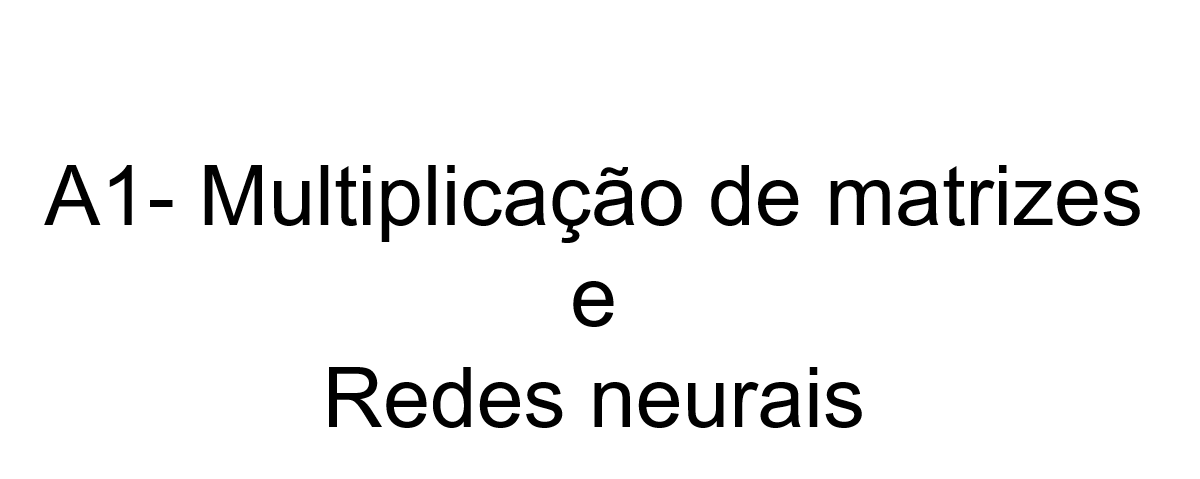

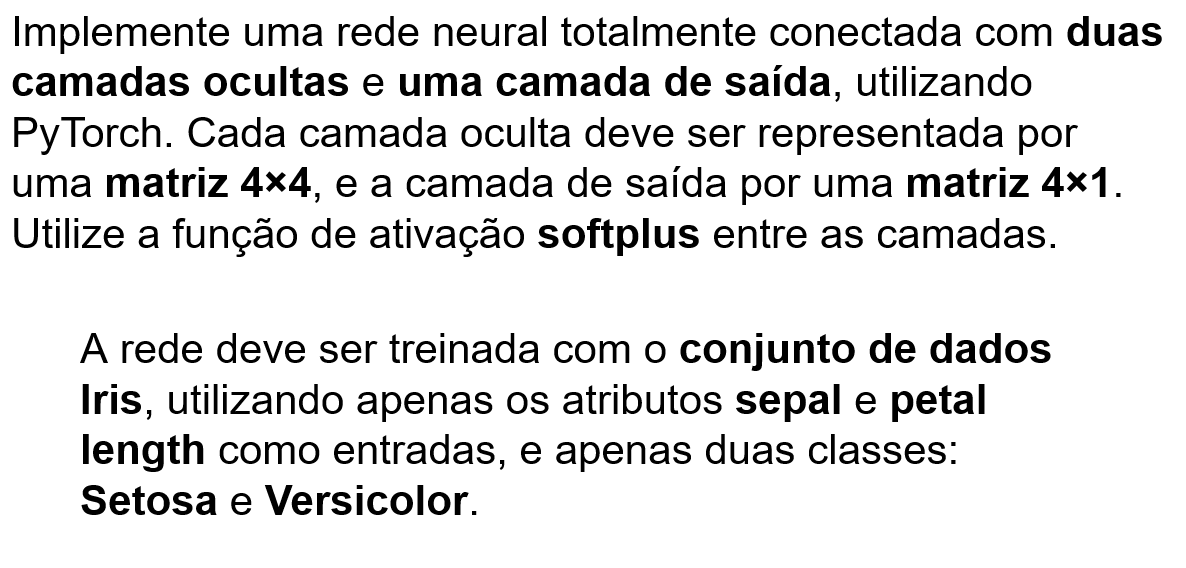

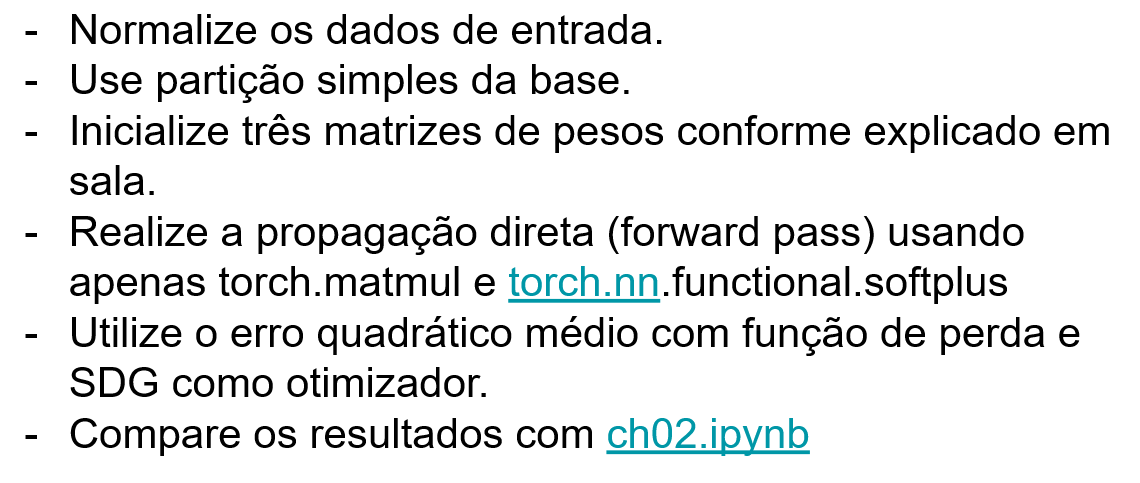

### Conceitos

#### Vazamento de Dados (*Data Leakage*) e Normalização

A normalização (`StandardScaler`) transforma os dados para que tenham média 0 e desvio padrão 1.

* **O Erro:** Se você normaliza a base inteira antes de separar o teste, o cálculo da média global inclui os dados de teste. O modelo "vislumbra" informações do futuro.
* **A Solução:** Usar `fit_transform` apenas no treino garante que os parâmetros estatísticos venham estritamente dele. O teste é transformado (`transform`) usando a régua calculada no treino.

#### Rede Neural Totalmente Conectada (*Fully Connected / Dense*)

Significa que cada neurônio de uma camada está conectado a todos os neurônios da camada seguinte. Matematicamente, calculamos essa transição usando a multiplicação de matrizes:

$$\mathbf{H} = f(\mathbf{X} \cdot \mathbf{W} + \mathbf{b})$$

No seu código, omitimos os vieses ($\mathbf{b}$) por simplicidade, realizando puramente o `torch.matmul(x, W)`. A compatibilidade das dimensões internas é obrigatória (ex: uma entrada de tamanho $N \times 2$ multiplicada por $2 \times 4$ resulta em uma matriz $N \times 4$).

#### Função de Ativação Softplus

A função **Softplus** é uma alternativa suave e derivável da famosa função ReLU. Ela é definida matematicamente como:

$$f(x) = \ln(1 + e^x)$$

> **Por que usar?** Ela introduz a não-linearidade necessária para a rede aprender padrões complexos. Sem uma função de ativação entre as camadas, a combinação de múltiplas multiplicações de matrizes seria equivalente a uma única operação linear, invalidando a existência de "camadas ocultas".

#### Erro Quadrático Médio (*MSE*) como Função de Perda

Embora o problema do Iris seja uma classificação binária (onde a Entropia Cruzada Binária costuma ser mais comum), o enunciado exigiu o **MSE**. Ele calcula a média dos quadrados das diferenças entre o valor real e o previsto:

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

Como o MSE assume valores contínuos na saída, a sua lógica de corte no teste (`pred >= 0.5`) mapeia perfeitamente essa saída contínua de volta para as classes discretas (0 ou 1).

#### Otimizador SGD (*Stochastic Gradient Descent*)

O Gradiente Descendente Estocástico é o mecanismo que atualiza as matrizes de pesos para reduzir o erro da rede.

1. O `loss.backward()` calcula as derivadas parciais do erro em relação a cada peso (gradientes) via *backpropagation*.
2. O `optimizer.step()` altera levemente os pesos na direção oposta ao gradiente usando a taxa de aprendizado (*learning rate*, `lr=0.01`).
3. O `optimizer.zero_grad()` limpa a memória desses gradientes para que eles não acumulem na próxima época de treino.

### Código

In [ ]:
# Carregando o Data Set das  Flores
iris = load_iris()

# Separando as features de interesse: (Sepal Length e Petal Length)
X = iris.data[:, [0, 2]]

# Separando apenas as classes requeridas: Setosa e Versicolor
mask = iris.target < 2

X = X[mask]
y = iris.target[mask]

In [ ]:
# Partição Simples do Data Set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [ ]:
# Processo de Normalização
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # Aprende e transforma o treino
X_test = scaler.transform(X_test)        # Apenas transforma o teste

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y.reshape(-1,1), dtype=torch.float32)

In [ ]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train.reshape(-1,1), dtype=torch.float32)
y_test = torch.tensor(y_test.reshape(-1,1), dtype=torch.float32)

In [ ]:
# Inicialização dos Pesos
W0 = torch.randn((2,4), requires_grad=True)  # Entrada (2) -> Oculta 1 (4)
W1 = torch.randn((4,4), requires_grad=True)  # Oculta 1 (4) -> Oculta 2 (4)
W2 = torch.randn((4,4), requires_grad=True)  # Oculta 2 (4) -> Oculta 3 (4)
W3 = torch.randn((4,1), requires_grad=True)  # Oculta 3 (4) -> Saída (1)

In [ ]:
# Forward: Utilizando torch.matmul e softplus
def forward(x):
    h0 = F.softplus(torch.matmul(x, W0))
    h1 = F.softplus(torch.matmul(h0, W1))
    h2 = F.softplus(torch.matmul(h1, W2))
    out = torch.matmul(h2, W3)  # Camada de saída pura para a Regressão/MSE
    return out

In [ ]:
# Função de Perda e Otimizador
criterion = torch.nn.MSELoss()
optimizer = optim.SGD([W0, W1, W2, W3], lr=0.01)

In [ ]:
# Treino:
epochs = 500

for epoch in range(epochs):
    optimizer.zero_grad()
    output = forward(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 50 == 0:
        print(f"Época {epoch+1}: Loss = {loss.item():.6f}")

Época 50: Loss = 0.241540
Época 100: Loss = 0.213862
Época 150: Loss = 0.194986
Época 200: Loss = 0.180760
Época 250: Loss = 0.169349
Época 300: Loss = 0.159810
Época 350: Loss = 0.151595
Época 400: Loss = 0.144358
Época 450: Loss = 0.137862
Época 500: Loss = 0.131935


In [ ]:
# Teste e Acurácia
with torch.no_grad():
    pred = forward(X_test)
    pred_class = (pred >= 0.5).float()
    accuracy = (pred_class == y_test).float().mean()

print(f"\nAcurácia: {accuracy.item()*100:.2f}%")


Acurácia: 93.33%


In [ ]:
# Previsões:
with torch.no_grad():
    pred = forward(X_test)
    pred_class = (pred >= 0.5).float()

for i in range(10):
    print(f"Real: {int(y_test[i].item())} | "f"Previsto: {int(pred_class[i].item())}")

Real: 1 | Previsto: 1
Real: 1 | Previsto: 1
Real: 1 | Previsto: 1
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 1 | Previsto: 1
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0


### Comparação de Resultados

## B1 ) Iris, mini-batches e redes neurais

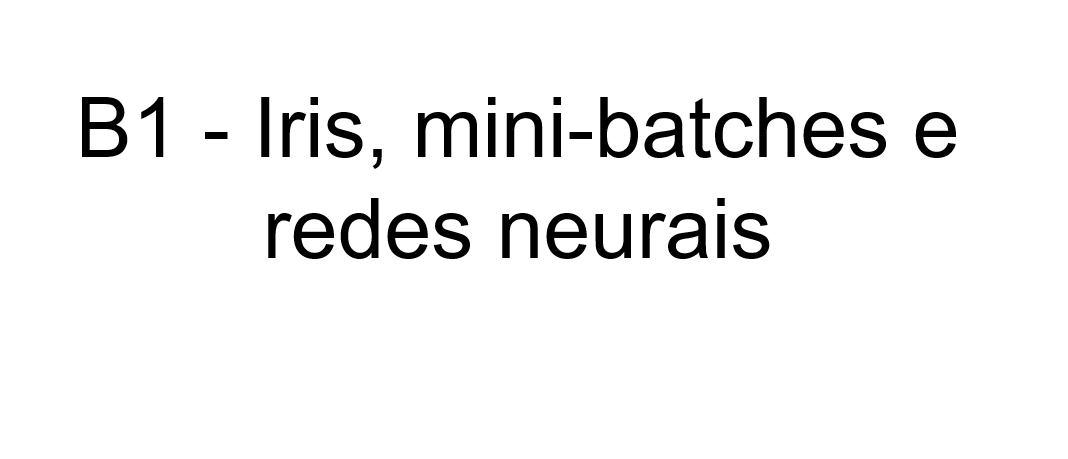

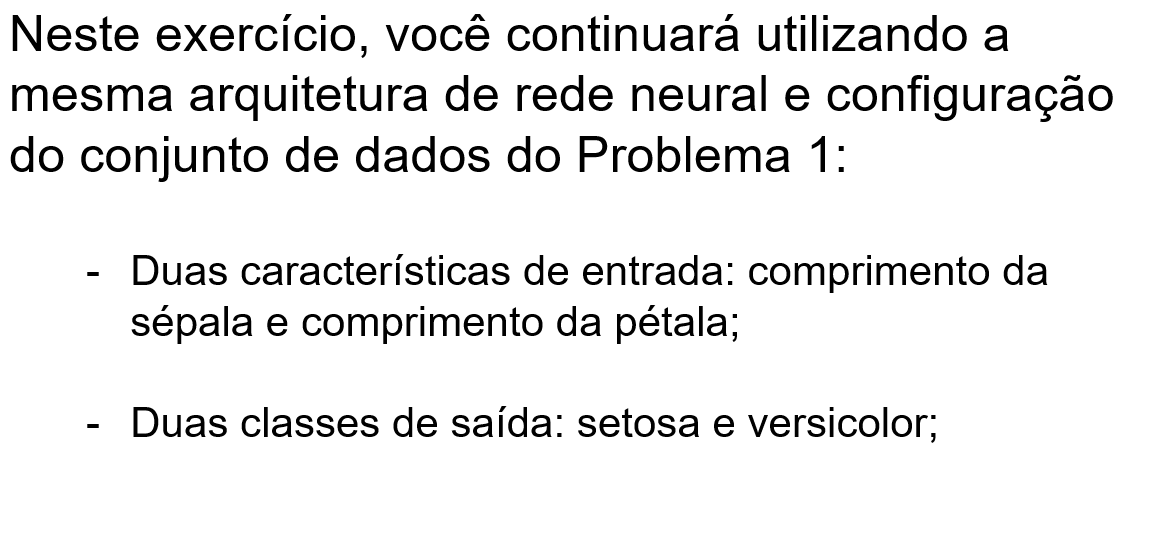

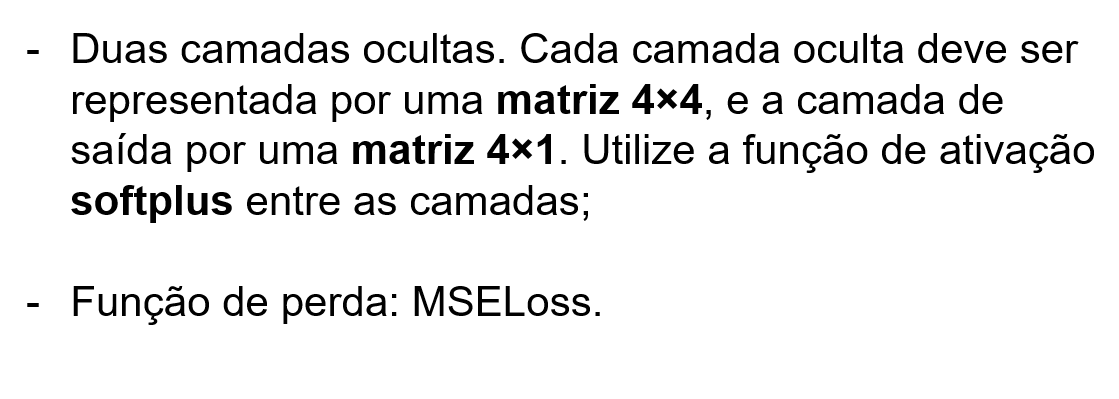

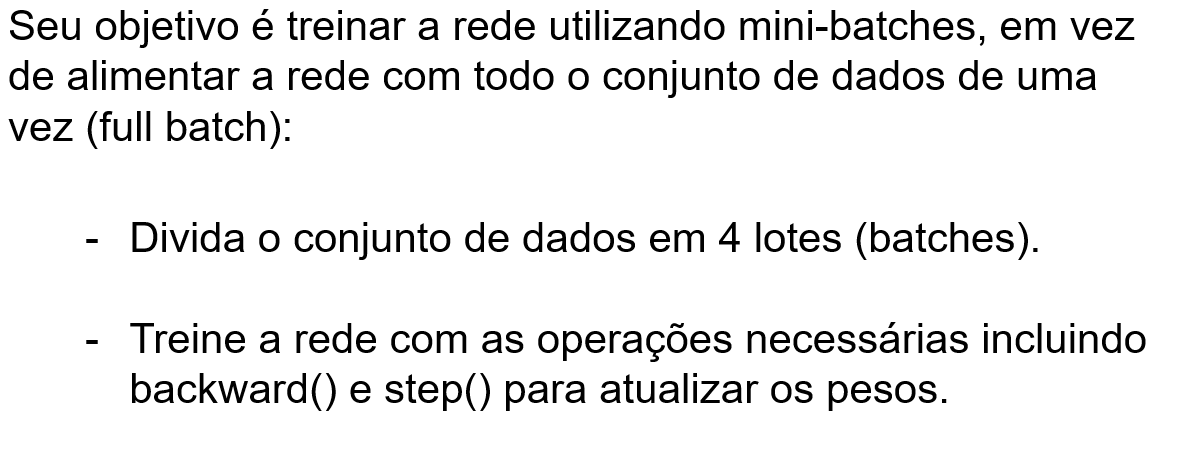

### Código

In [ ]:
iris = load_iris()
# Apenas Sepal Length e Petal Length
X = iris.data[:, [0, 2]]
# Apenas Setosa e Versicolor
mask = iris.target < 2

X = X[mask]
y = iris.target[mask]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train.reshape(-1,1), dtype=torch.float32)
y_test = torch.tensor(y_test.reshape(-1,1), dtype=torch.float32)

In [ ]:
torch.manual_seed(42)

W0 = torch.randn((2,4), requires_grad=True)  # Entrada (2) -> Oculta 1 (4)
W1 = torch.randn((4,4), requires_grad=True)  # Oculta 1 (4) -> Oculta 2 (4)
W2 = torch.randn((4,4), requires_grad=True)  # Oculta 2 (4) -> Oculta 3 (4)
W3 = torch.randn((4,1), requires_grad=True)  # Oculta 3 (4) -> Saída (1)

In [ ]:
def forward(x):
    h0 = F.softplus(torch.matmul(x, W0))
    h1 = F.softplus(torch.matmul(h0, W1))
    h2 = F.softplus(torch.matmul(h1, W2))
    out = torch.matmul(h2, W3)

    return out

In [ ]:
criterion = torch.nn.MSELoss()
optimizer = optim.SGD([W0, W1, W2, W3], lr=0.01)

In [ ]:
# Dividindo o Data Set em 4 mini-batches
batch_size = math.ceil(len(X_train) / 4)
print(batch_size)

18


In [ ]:
# Treino com mini-batches
epochs = 500

for epoch in range(epochs):
    # Embaralha os índices a cada época
    indices = torch.randperm(len(X_train))

    epoch_loss = 0.0
    num_batches = 0

    for i in range(0, len(X_train), batch_size):
        # Seleciona os índices do lote atual
        batch_indices = indices[i:i+batch_size]

        X_batch = X_train[batch_indices]
        y_batch = y_train[batch_indices]

        optimizer.zero_grad()
        output = forward(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

    # Exibe a média da perda de todos os batches daquela época
    if (epoch + 1) % 50 == 0:
        print(f"Época {epoch+1}: Loss Média = {epoch_loss / num_batches:.6f}")

Época 50: Loss Média = 0.028067
Época 100: Loss Média = 0.023014
Época 150: Loss Média = 0.018893
Época 200: Loss Média = 0.014229
Época 250: Loss Média = 0.010997
Época 300: Loss Média = 0.009994
Época 350: Loss Média = 0.009130
Época 400: Loss Média = 0.008990
Época 450: Loss Média = 0.008302
Época 500: Loss Média = 0.008489


In [ ]:
# Avaliando
with torch.no_grad():
    output = forward(X_test)
    pred = (output >= 0.5).float()
    accuracy = (pred == y_test).float().mean()

print(f"\nAcurácia: {accuracy.item()*100:.2f}%")


Acurácia: 100.00%


In [ ]:
# Previsões
print("\nAmostra de Previsões: ")
for i in range(10):
    print(
        f"Real: {int(y_test[i].item())} | "
        f"Previsto: {int(pred[i].item())}"
    )


Amostra de Previsões: 
Real: 1 | Previsto: 1
Real: 1 | Previsto: 1
Real: 1 | Previsto: 1
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 1 | Previsto: 1
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0


## B-1.2 ) Temático, mini-batches e redes neurais

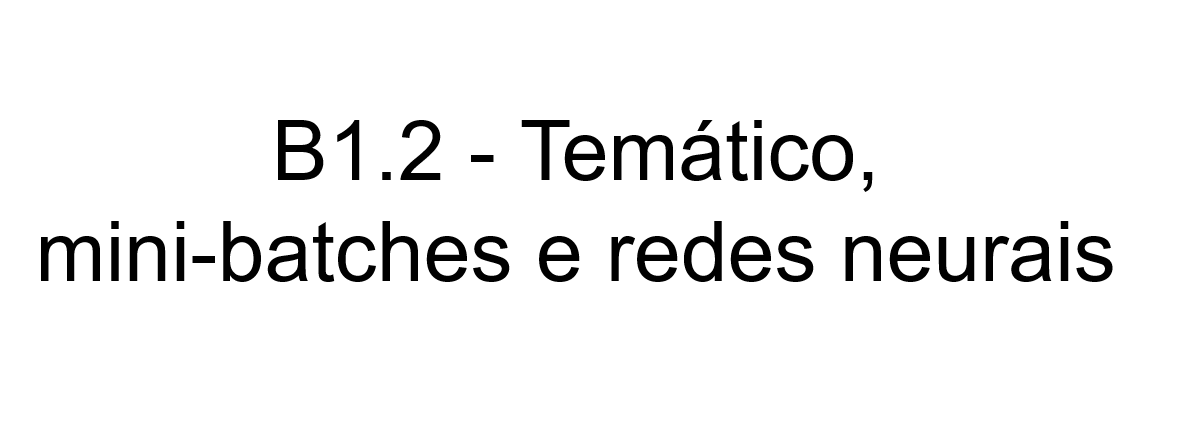

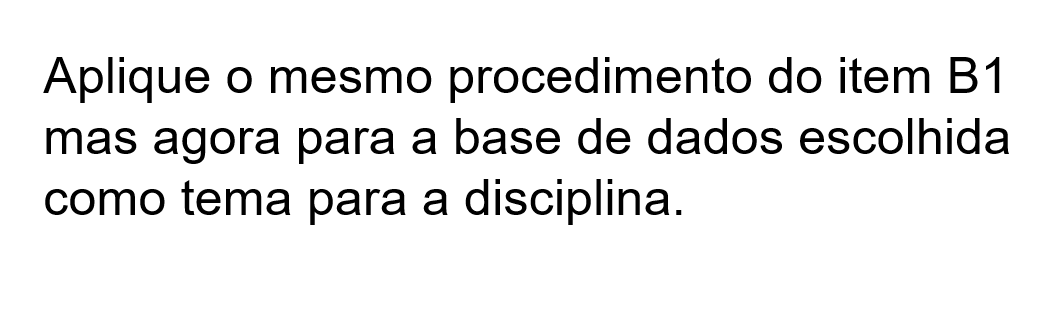

### Código

In [ ]:
# Apenas classes 1 e 2
df = df[df["seedType"].isin([1, 2])]

# Entradas
X = df[["area", "lengthOfKernel"]].values
# Saída
y = df["seedType"].values

# Transforma as classes em 0 e 1 (Classe 1 virará 0, Classe 2 virará 1)
y = (y == 2).astype(float)

In [ ]:
# Partição Simples feita antes da normalização para evitar Data Leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Aplicando Normalização corretamente isolada por partição
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # Aprende e transforma o treino
X_test = scaler.transform(X_test)        # Apenas transforma o teste

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train.reshape(-1,1), dtype=torch.float32)
y_test = torch.tensor(y_test.reshape(-1,1), dtype=torch.float32)

In [ ]:
# Inicialização dos Pesos
torch.manual_seed(42)

W0 = torch.randn((2,4), requires_grad=True)
W1 = torch.randn((4,4), requires_grad=True)
W2 = torch.randn((4,4), requires_grad=True)
W3 = torch.randn((4,1), requires_grad=True)

In [ ]:
def forward(x):
    h0 = F.softplus(torch.matmul(x, W0))
    h1 = F.softplus(torch.matmul(h0, W1))
    h2 = F.softplus(torch.matmul(h1, W2))
    out = torch.matmul(h2, W3)
    return out

In [ ]:
criterion = torch.nn.MSELoss()
optimizer = optim.SGD([W0, W1, W2, W3], lr=0.01)

In [ ]:
# Ajuste matemático para garantir exatamente 4 mini-batches
batch_size = math.ceil(len(X_train) / 4)

In [ ]:
# Treinamento
epochs = 500

for epoch in range(epochs):
    # Gera uma permutação aleatória dos índices a cada época
    indices = torch.randperm(len(X_train))

    epoch_loss = 0.0
    num_batches = 0

    for i in range(0, len(X_train), batch_size):
        # Seleciona os índices do lote sem sobrescrever ou reordenar a matriz original
        batch_indices = indices[i:i+batch_size]

        X_batch = X_train[batch_indices]
        y_batch = y_train[batch_indices]

        optimizer.zero_grad()
        output = forward(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

    # Printando a Loss média real da época inteira
    if (epoch+1) % 50 == 0:
        print(f"Época {epoch+1}: Loss Média = {epoch_loss / num_batches:.6f}")

Época 50: Loss Média = 0.114198
Época 100: Loss Média = 0.106350
Época 150: Loss Média = 0.104575
Época 200: Loss Média = 0.101539
Época 250: Loss Média = 0.098606
Época 300: Loss Média = 0.098827
Época 350: Loss Média = 0.094593
Época 400: Loss Média = 0.091003
Época 450: Loss Média = 0.094491
Época 500: Loss Média = 0.088000


In [ ]:
# Teste
with torch.no_grad():
    output = forward(X_test)
    pred = (output >= 0.5).float()
    accuracy = (pred == y_test).float().mean()

print(f"\nAcurácia no Teste: {accuracy.item()*100:.2f}%")


Acurácia no Teste: 95.24%


## C-1 ) Rede Neural com Separação Linear


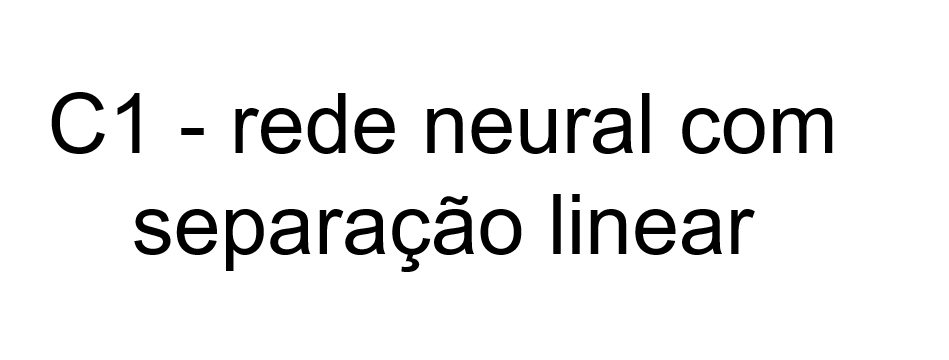

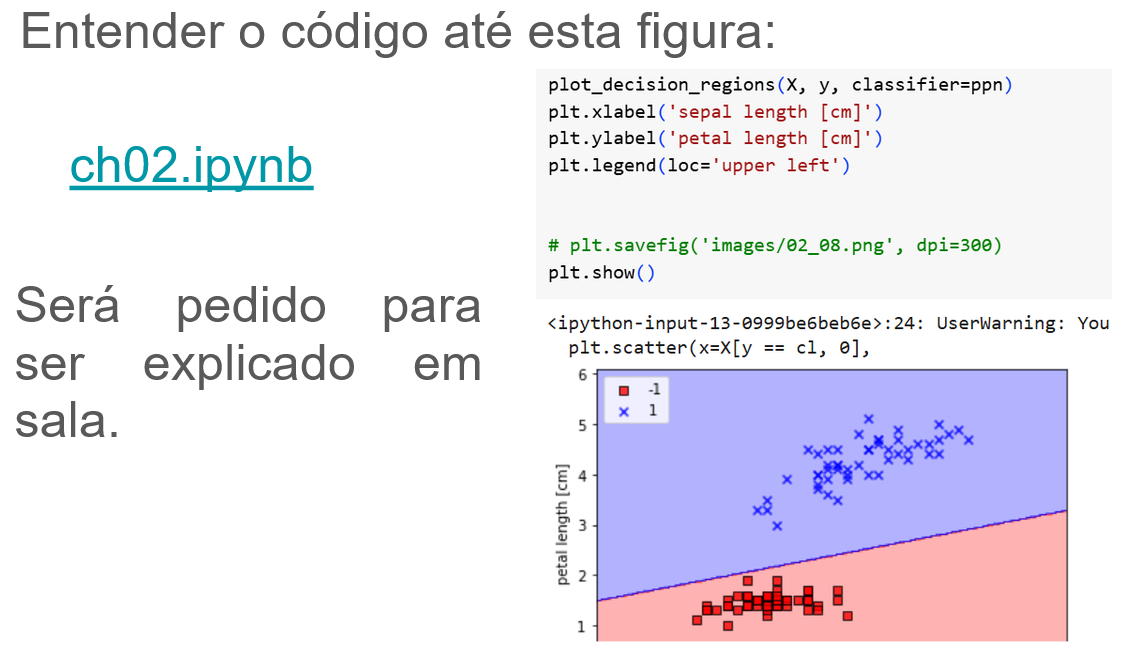

### Explicação do Código

#### Classificação de Flores com o Algoritmo Perceptron

O código tem como objetivo principal ensinar uma rede a diferenciar dois tipos diferentes de flores da base de dados Iris com base no tamanho de suas pétalas e sépalas. Para isso, se cria, treina e visualiza um modelo de Perceptron.

---

#### O Objetivo Geral do Código

Resumidamento o código lê o Dataset Iris, separa duas classes específicas, treina um classificador para aprender a diferença entre elas e, por último, desenha uma linha de decisão no gráfico. Essa linha divide o gráfico em duas áreas coloridas: tudo o que cair na região vermelha é classificado como classe 0, e o que cair na região azul é a classe 1.

---

#### Modelo Perceptron

No início, o código define a estrutura do Perceptron. Ele funciona como um neurônio artificial simples.

* Ele recebe as características da flor (comprimento da sépala e da pétala).
* Ele faz uma aposta de qual flor se trata.
* Se ele errar, ele ajusta seus "pesos" internos (aprende com o erro) usando uma taxa de aprendizado. Ele repete esse processo várias vezes (épocas) até parar de errar.

---

#### Preparação dos Dado

O código lê os dados do Dataset e faz:

* Filtra as primeiras 100 linhas, que contêm apenas duas espécies: *Iris-setosa* e *Iris-versicolor*.
* Transforma os nomes das flores em números: `-1` para Setosa e `1` para Versicolor (binarizar o problema).
* Extrai apenas duas colunas de características: o **comprimento da sépala** e o **comprimento da pétala** para servirem como as coordenadas $X$ e $Y$ do gráfico.

---

#### Treinamento(Aprendizado do Neurônio)

Com os dados prontos, o código cria o classificador (`ppn = Perceptron(...)`) e manda ele rodar o processo de ajuste 10 vezes (`n_iter=10`) em cima do Dataset através da função `fit`.

O código também gera um gráfico intermediário para mostrar o número de erros caindo a cada rodada, provando que o modelo está de fato aprendendo e deixando de errar.

---

#### Mapeamento e Gráfico

A função `plot_decision_regions` é responsável pelo plot do gráfico:

* Ela cria uma barreira invisível cheia de pontos cobrindo todo o gráfico.
* A função, usando o Perceptron treinado,  tenta adivinhar a classe de *cada um* dos pontos gerados.
* Se o modelo diz que o ponto é da classe `-1`, a função pinta o fundo de **vermelho**. Se diz que é `1`, pinta de **azul**.

---

#### Resultado

Por fim, o código joga os pontos reais do Dataset por cima desse fundo colorido:

* Os **quadrados vermelhos** são as flores do tipo *Setosa* (classe -1).
* Os **xis azuis** são as flores do tipo *Versicolor* (classe 1).

A linha reta que separa a região azul da vermelha é a **fronteira de decisão** que o Perceptron descobriu sozinho.

## C-1.2 ) Rede Neural com Separação Linear Temático

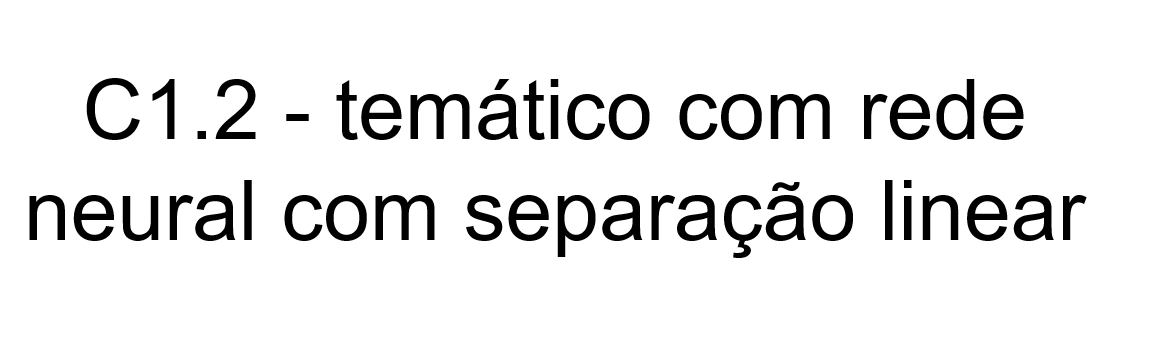

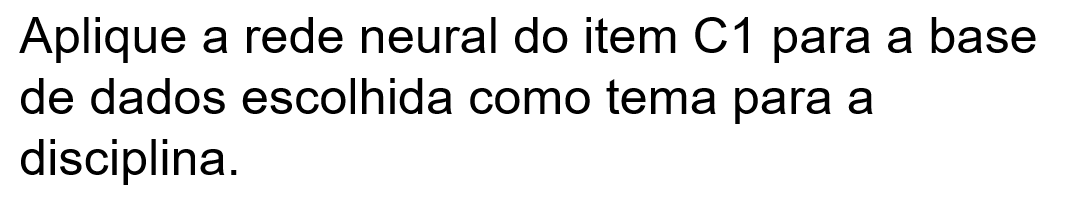

### Código

#### Código do Perceptron

Reutilzando o mesmo Perceptron do código da questão anterior **(C-1)**:

In [ ]:
class Perceptron(object):
    """Perceptron classifier.

    Parameters
    ------------
    eta : float
      Learning rate (between 0.0 and 1.0)
    n_iter : int
      Passes over the training dataset.
    random_state : int
      Random number generator seed for random weight
      initialization.

    Attributes
    -----------
    w_ : 1d-array
      Weights after fitting.
    errors_ : list
      Number of misclassifications (updates) in each epoch.

    """
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        """Fit training data.

        Parameters
        ----------
        X : {array-like}, shape = [n_examples, n_features]
          Training vectors, where n_examples is the number of examples and
          n_features is the number of features.
        y : array-like, shape = [n_examples]
          Target values.

        Returns
        -------
        self : object

        """
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.errors_ = []

        for _ in range(self.n_iter):
            errors = 0
            for xi, target in zip(X, y):
                update = self.eta * (target - self.predict(xi))
                self.w_[1:] += update * xi
                self.w_[0] += update
                errors += int(update != 0.0)
            self.errors_.append(errors)
        return self

    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def predict(self, X):
        """Return class label after unit step"""
        return np.where(self.net_input(X) >= 0.0, 1, -1)

#### Código da Fronteira de Decisão

Reutilzando a mesma função de gráfico de Fronteira de Decisão do código da questão anterior **(C-1)**:

In [ ]:
def plot_decision_regions(X, y, classifier, resolution=0.02):

    # setup marker generator and color map
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # plot class examples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],
                    y=X[y == cl, 1],
                    alpha=0.8,
                    c=colors[idx],
                    marker=markers[idx],
                    label=cl,
                    edgecolor='black')

#### Código para o Data Set de Sementes

In [ ]:
# Selecionando apenas duas classes do meu data set, já que o perceptron é binário
df = df[df["seedType"].isin([1, 2])]

y = df["seedType"].values
y = np.where(y == 1, -1, 1)

# Separando duas features do meu Data Set
X = df[["area", "lengthOfKernel"]].values

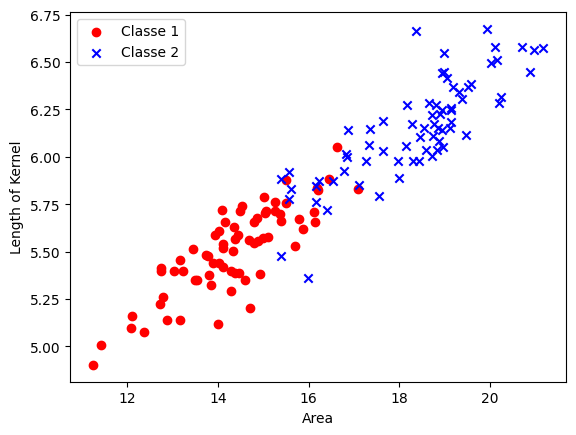

In [ ]:
# Visualização dos dados com Gráfico
plt.scatter(X[y==-1,0], X[y==-1,1], color="red", marker="o", label="Classe 1")
plt.scatter(X[y==1,0], X[y==1,1], color="blue", marker="x", label="Classe 2")

plt.xlabel("Area")
plt.ylabel("Length of Kernel")
plt.legend()

plt.show()

In [ ]:
# Treinando o Perceptron
ppn = Perceptron(eta=0.1, n_iter=10)
ppn.fit(X, y)

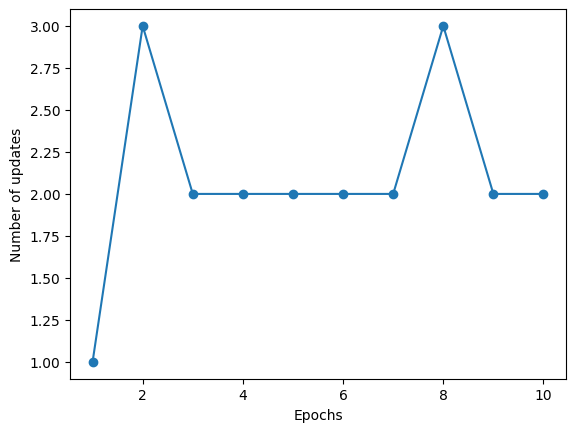

In [ ]:
# Gráfico de Erros por Época
plt.plot(range(1, len(ppn.errors_)+1), ppn.errors_, marker='o')

plt.xlabel("Epochs")
plt.ylabel("Number of updates")

plt.show()

/tmp/ipykernel_38926/3161056731.py:21: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


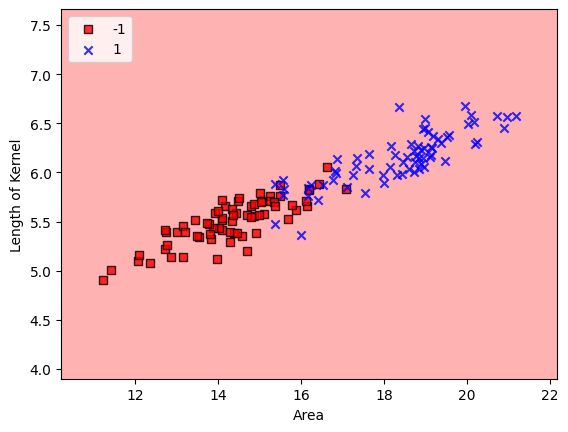

In [ ]:
# Gráfico da Fronteira de Decisão
plot_decision_regions(X, y, classifier=ppn)

plt.xlabel("Area")
plt.ylabel("Length of Kernel")
plt.legend(loc="upper left")

plt.show()

## D-1 ) Dataset Linearmente Separável

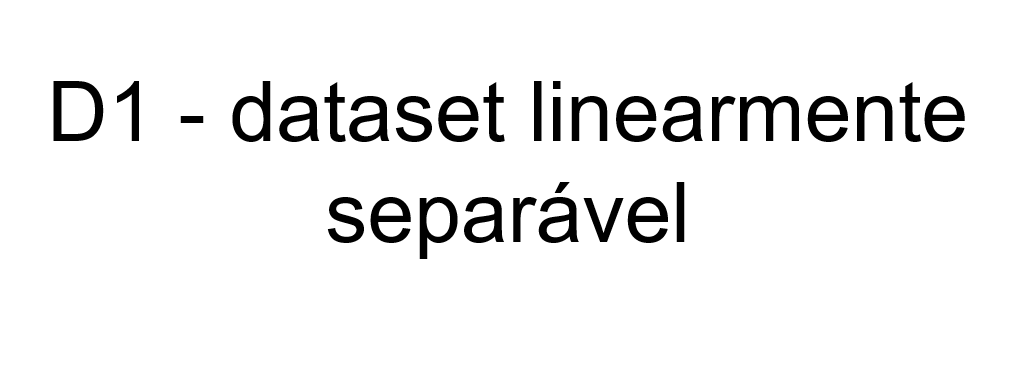

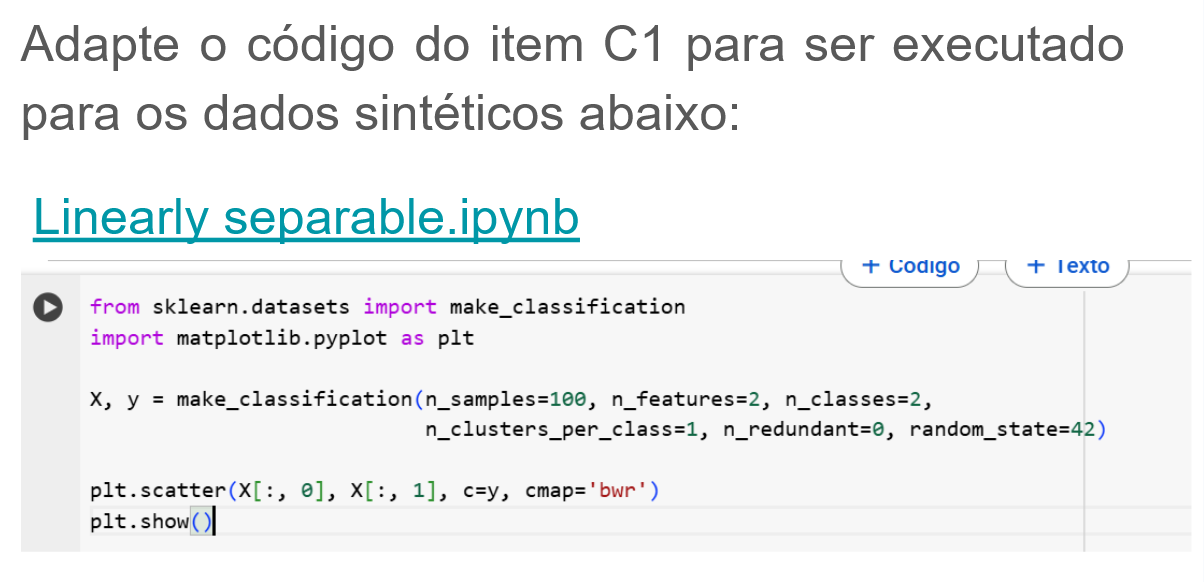

### O que foi Alterado

#### Origem e Geração dos Dados

* **O que mudou:** A leitura de dados específicos de uma tabela do Pandas (`df`) foi totalmente substituída pela função automática `make_classification` do Scikit-Learn.
* **Por que mudou:** O objetivo do exercício era desvincular o algoritmo de um problema real específico (como o das sementes) e testá-lo em um ambiente controlado. Essa função gera uma matriz NumPy sintética na hora, eliminando a necessidade de carregar arquivos externos ou filtrar colunas manualmente.

#### Mapeamento das Classes Alvo

* **O que mudou:** A função de conversão de rótulos foi ajustada de `np.where(y == 1, -1, 1)` para `np.where(y == 0, -1, 1)`.
* **Por que mudou:** O gerador de dados do Scikit-Learn entrega por padrão as classes binárias representadas por `0` e `1`. Como a matemática clássica do Perceptron depende estritamente dos valores `-1` e `1` para calcular os erros e atualizar os pesos corretamente através da função de degrau unitário, o mapeamento do `0` para `-1` tornou-se obrigatório para o modelo convergir.

#### Generalização dos Eixos e Rótulos dos Gráficos

* **O que mudou:** As legendas específicas de eixos (`Area` e `Length of Kernel`) e os filtros baseados no formato de DataFrame foram alterados para termos genéricos (`Feature 1` e `Feature 2`) usando indexação pura de matrizes NumPy.
* **Por que mudou:** Como os novos dados são gerados artificialmente por equações estatísticas, eles perdem o sentido físico ou biológico. Utilizar nomenclaturas genéricas mantém o código correto do ponto de vista conceitual e pronto para ser reutilizado com qualquer outro conjunto de dados bidimensional.

### Código

In [ ]:
X, y = make_classification(n_samples=100, n_features=2, n_classes=2, n_clusters_per_class=1, n_redundant=0,random_state=42)
# O perceptron utiliza classes -1 e +1
y = np.where(y == 0, -1, 1)

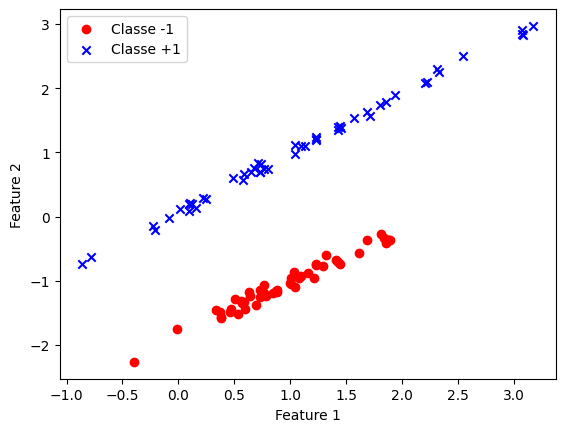

In [ ]:
# Gráfico
plt.scatter(X[y==-1,0], X[y==-1,1], color='red', marker='o', label='Classe -1')

plt.scatter(X[y==1,0], X[y==1,1], color='blue', marker='x', label='Classe +1')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()

plt.show()

In [ ]:
ppn = Perceptron(eta=0.1,n_iter=10)
ppn.fit(X, y)

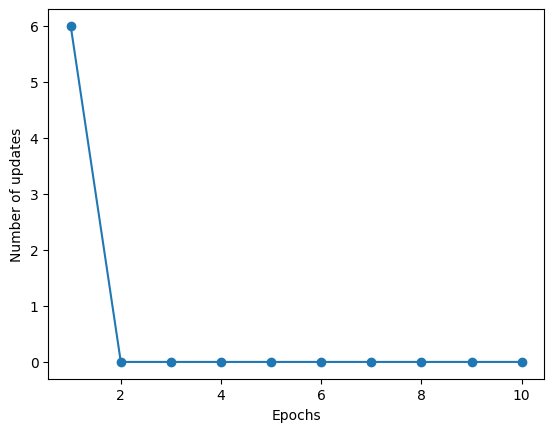

In [ ]:
plt.plot(range(1, len(ppn.errors_) + 1), ppn.errors_,marker='o')

plt.xlabel("Epochs")
plt.ylabel("Number of updates")

plt.show()

/tmp/ipykernel_38926/3161056731.py:21: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


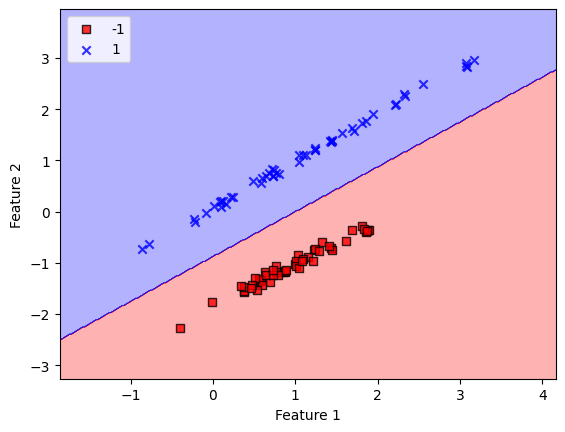

In [ ]:
plot_decision_regions(X, y, classifier=ppn)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(loc='upper left')

plt.show()

## E-1 ) Gradiente Descendente Estocástico

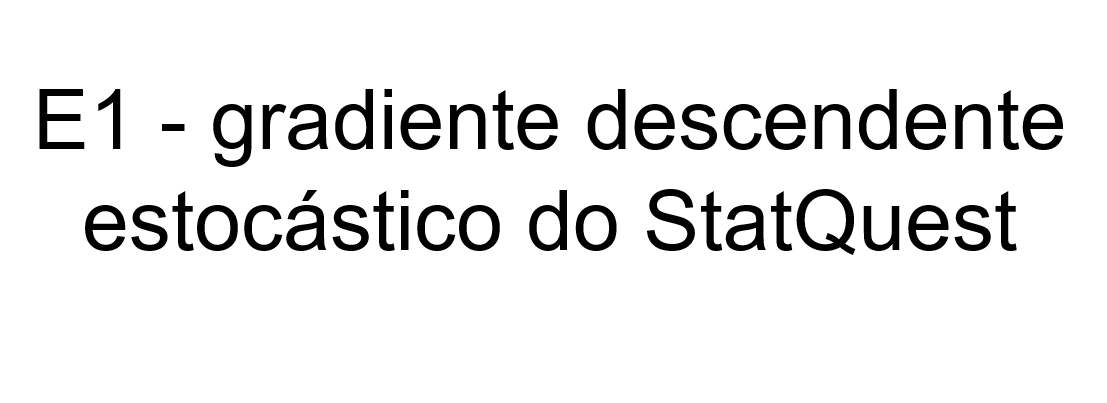

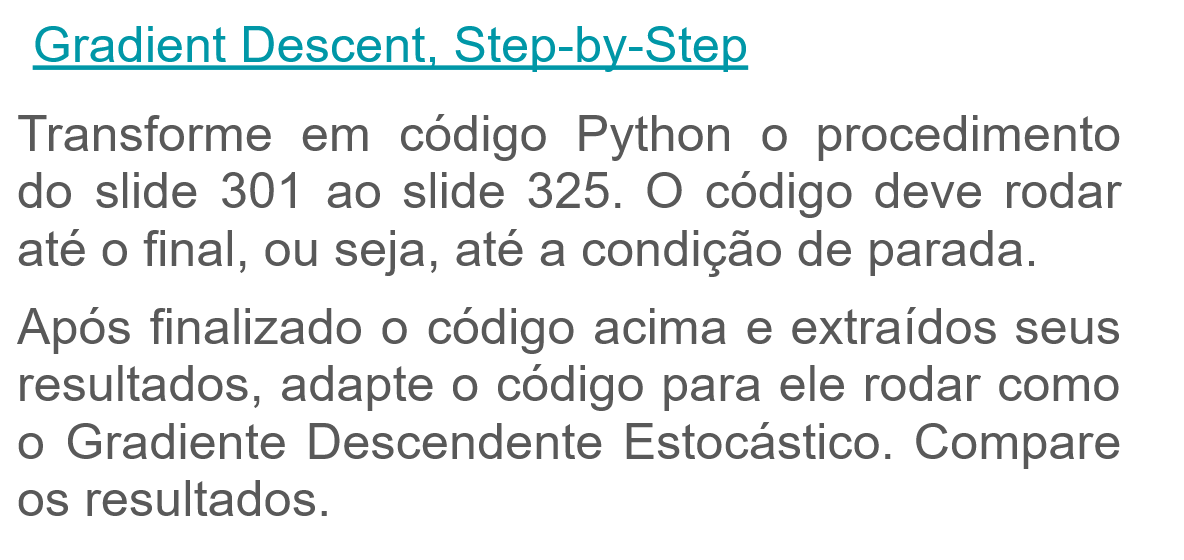

### Conceitos

#### Regressão Linear

A regressão linear é uma técnica utilizada para modelar a relação entre uma variável independente (peso) e uma variável dependente (altura). O modelo é representado pela equação:

$$ \hat{y} = mx + b $$

onde:
- $(m)$ é o coeficiente angular (*slope*), que representa a inclinação da reta;
- $(b)$ é o coeficiente linear (*intercept*), que representa o ponto onde a reta intercepta o eixo \(y\);
- $(x)$ é a variável de entrada;
- $(\hat{y})$ é o valor previsto pelo modelo.

#### SSR (Sum of Squared Residuals)

A SSR (Soma dos Quadrados dos Resíduos) é a função de custo utilizada para medir o erro do modelo. Ela calcula a diferença entre os valores observados e os valores previstos pela regressão linear.

$$ SSR = \sum_{i=1}^{n}(y_i-\hat{y_i})^2 $$

Quanto menor o valor da SSR, melhor a reta se ajusta aos dados.

#### Descida de Gradiente (Gradient Descent)

A Descida de Gradiente é um algoritmo de otimização utilizado para minimizar a função de custo. A cada iteração são calculadas as derivadas da SSR em relação aos parâmetros da reta, indicando a direção de maior crescimento do erro. Em seguida, os parâmetros são atualizados no sentido oposto ao gradiente, reduzindo progressivamente o erro.

As atualizações são realizadas pelas equações:

$$ m = m - \alpha\frac{\partial SSR}{\partial m}$$

$$ b = b - \alpha\frac{\partial SSR}{\partial b}$$

onde:
- $(\alpha)$ é a taxa de aprendizado (*learning rate*);
- $(m)$ é o coeficiente angular;
- $(b)$ é o coeficiente linear.

#### Taxa de Aprendizado (Learning Rate)

A taxa de aprendizado determina o tamanho do passo dado a cada atualização dos parâmetros. Valores muito altos podem fazer o algoritmo divergir, enquanto valores muito baixos tornam a convergência mais lenta.

#### Critério de Convergência

O algoritmo é executado repetidamente até que o tamanho das atualizações dos parâmetros seja menor que um valor mínimo estabelecido. Quando isso ocorre, considera-se que o modelo encontrou uma solução suficientemente próxima do mínimo da função de custo.

### Código

#### Gradiente Descendente

In [ ]:
# Valores base retirados do slide
h_observada = [1.4, 1.9, 3.2]
peso = [0.5, 2.3, 2.9]

# Valores base para a Descida de Gradiente
lr = 0.1
max_steps = 100
m_step_size = 0.0001

In [ ]:
# Funções do Gradiente Descendente
def predicted_H(slope, intercept, peso):
    return slope * peso + intercept

def ssr(h_observada, slope, intercept, peso):
    return sum([(h_observada[i] - predicted_H(slope, intercept, peso[i])) ** 2 for i in range(len(peso))])

def derivada_ssr_intercept(h_observada, peso, slope, intercept):
    return sum([-2 * (h_observada[i] - predicted_H(slope, intercept, peso[i])) for i in range(len(peso))])

def derivada_ssr_slope(h_observada, peso, slope, intercept):
    return sum([-2 * peso[i] * (h_observada[i] - predicted_H(slope, intercept, peso[i])) for i in range(len(peso))])

def Gradient_Descent_Coordenado(slope_inicial, intercept_inicial, lr_intercept, lr_slope, max_rounds, minimum_step):
    slope = slope_inicial
    intercept = intercept_inicial

    slope_history = []
    intercept_history = []
    ssr_history = []

    print("=" * 100)
    print(f"{'Rodada':^8} {'Intercepto':^15} {'Slope':^15} {'SSR':^18}")
    print("=" * 100)

    for r in range(max_rounds):
        # Passo do intercept: usa o slope mais atual
        grad_int = derivada_ssr_intercept(h_observada, peso, slope, intercept)
        step_int = grad_int * lr_intercept
        intercept -= step_int

        # Passo do slope: usa o intercept recém atualizado
        grad_slope = derivada_ssr_slope(h_observada, peso, slope, intercept)
        step_slope = grad_slope * lr_slope
        slope -= step_slope

        valor_ssr = ssr(h_observada, slope, intercept, peso)

        intercept_history.append(intercept)
        slope_history.append(slope)
        ssr_history.append(valor_ssr)

        print(f"{r+1:^8} {intercept:^15.6f} {slope:^15.6f} {valor_ssr:^18.6f}")

        if abs(step_int) < minimum_step and abs(step_slope) < minimum_step:
            print("=" * 100)
            print(f"Convergência atingida na rodada {r+1}.")
            print(f"Intercepto ideal = {intercept:.6f}")
            print(f"Slope ideal = {slope:.6f}")
            print(f"SSR final = {valor_ssr:.6f}")
            print("=" * 100)
            break

    return slope, intercept, slope_history, intercept_history, ssr_history

slope_final, intercept_final, slope_history, intercept_history, ssr_history = Gradient_Descent_Coordenado(1, 0, 0.1, 0.1, max_steps, m_step_size)

 Rodada    Intercepto         Slope             SSR        
   1        0.160000        0.897600          0.922219     
   2        0.340736        0.874857          0.695603     
   3        0.438957        0.803595          0.648131     
   4        0.559485        0.793753          0.546825     
   5        0.618916        0.743618          0.532029     
   6        0.699841        0.741104          0.486211     
   7        0.735078        0.705435          0.482545     
   8        0.789835        0.706859          0.461565     
   9        0.810115        0.681191          0.461288     
   10       0.847488        0.684531          0.451555     
   11       0.858629        0.665851          0.452065     
   12       0.884381        0.669931          0.447488     
   13       0.890031        0.656188          0.448011     
   14       0.907958        0.660352          0.445830     
   15       0.910382        0.650135          0.446201     
   16       0.922999        0.654040    

#### Gradiente Descendente Estocástico


In [ ]:
# Dados retirados do slide
h_observada = [1.4, 1.9, 3.2]
peso = [0.5, 2.3, 2.9]

lr = 0.01
max_steps = 1000
m_step_size = 0.0001

In [ ]:
# Funções
def predicted_H(slop, intercepto, weight):
    return slop * weight + intercepto

def d_intercept(indices, slop, intercepto):
    return sum([-2*(h_observada[i] - predicted_H(slop, intercepto, peso[i])) for i in indices])

def d_slope(indices, slop, intercepto):
    return sum([-2*peso[i]*(h_observada[i] - predicted_H(slop, intercepto, peso[i])) for i in indices])

def Gradient_Descent_Stochastic(lr, max_steps, min_step):
    slope = 1
    intercept = 0

    for step in range(max_steps):
        i = random.randint(0, 2)   # escolhe 1

        d_slop = d_slope([i], slope, intercept)
        d_intercepto = d_intercept([i], slope, intercept)

        slope = slope - lr * d_slop
        intercept = intercept - lr * d_intercepto

        if abs(lr*d_intercepto) < min_step:
            break

    return intercept, slope


In [ ]:
intercept, slope = Gradient_Descent_Stochastic(lr, max_steps, m_step_size)

print(f" Gradiente Descendente Estocástico(1 amostra por passo):\n intercept: {intercept} \n slope: {slope}")

 Gradiente Descendente Estocástico(1 amostra por passo):
 intercept: 0.9126962189524008 
 slope: 0.42922545606559526


### Resultados

O algoritmo de **Gradiente Descendente** convergiu após **53 iterações**, encontrando os valores:

- **Intercepto:** 0.948670
- **Slope:** 0.640984

Já o **Gradiente Descendente Estocástico (SGD)**, utilizando **uma amostra por atualização**, ele tem valores que variam drasticamente a cada vez que o código é rodado, mas os valores chegam muito próximos de resultados considerados "ótimos".

Observa-se que ambos os algoritmos produziram parâmetros bastante próximos, indicando que conseguiram encontrar soluções semelhantes para o problema de regressão linear. A pequena diferença entre os valores é esperada, pois o Gradiente Descendente Estocástico atualiza os parâmetros utilizando apenas uma amostra por vez, tornando sua trajetória mais sujeita a oscilações.

O Gradiente Descendente tradicional calcula o gradiente considerando todo o conjunto de dados em cada iteração, resultando em uma trajetória mais estável e uma convergência mais suave em direção ao mínimo da função de custo. Em contrapartida, o Gradiente Descendente Estocástico realiza atualizações mais frequentes, porém com maior variabilidade, o que pode fazer com que os parâmetros finais não coincidam exatamente com os obtidos pelo método tradicional.

Apesar dessa diferença, os valores finais do intercepto e do slope permaneceram muito próximos, demonstrando que ambos os métodos foram capazes de ajustar adequadamente a reta aos dados disponíveis. Em conjuntos de dados maiores, o Gradiente Descendente Estocástico costuma apresentar vantagem em termos de tempo de processamento, enquanto o Gradiente Descendente convencional tende a produzir uma convergência mais estável e precisa.

## F-1 ) Pytorch e Rede Neural

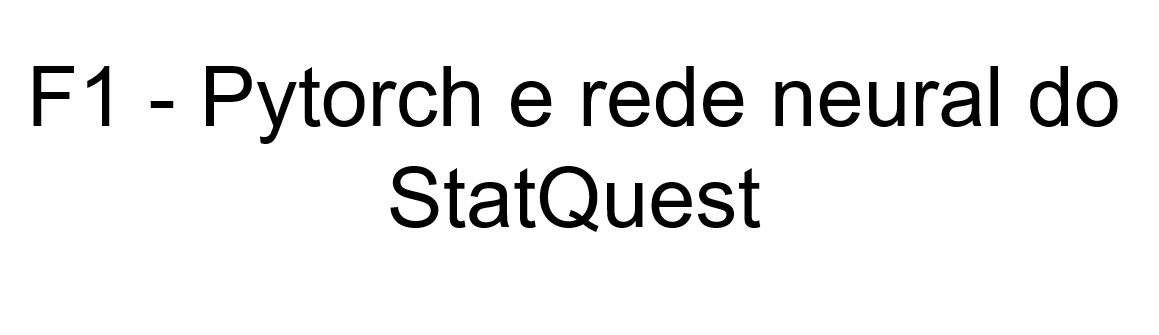

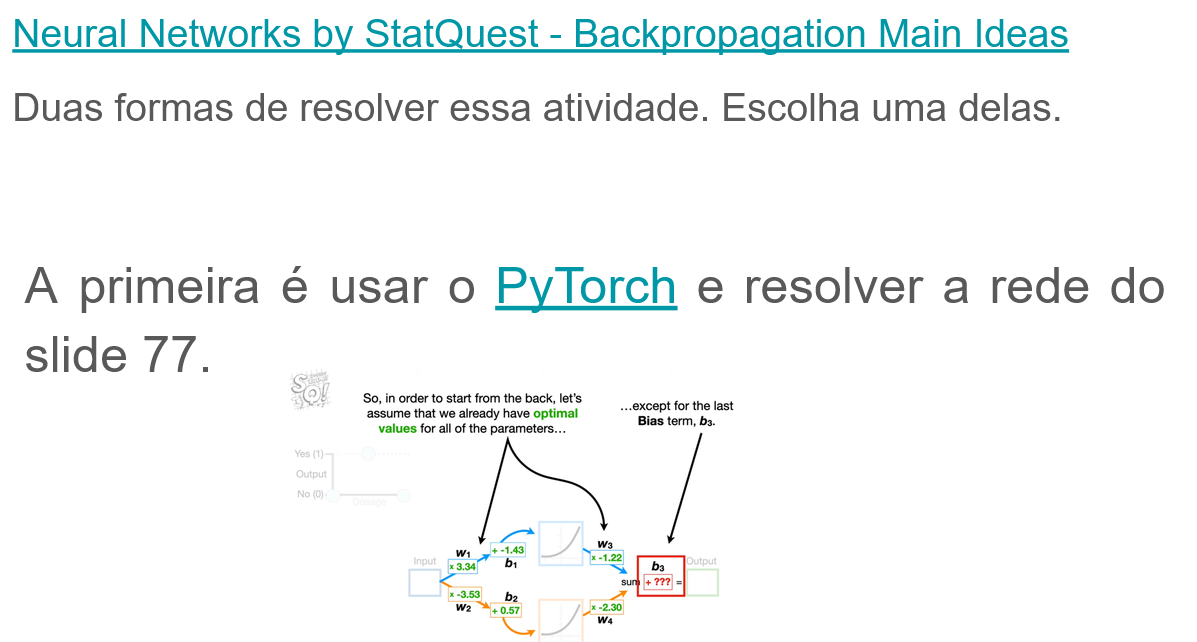

### Conceito

#### PyTorch

O PyTorch é uma biblioteca de aprendizado de máquina desenvolvida para a construção e treinamento de modelos de inteligência artificial. Sua principal característica é oferecer uma forma simples de definir redes neurais por meio de classes, tensores e mecanismos automáticos de cálculo de derivadas. Neste código, o PyTorch é utilizado para criar a arquitetura da rede, armazenar os parâmetros do modelo, calcular a função de custo e atualizar automaticamente o parâmetro treinável utilizando o algoritmo de otimização.

#### Redes Neurais Artificiais

Uma Rede Neural Artificial (RNA) é um modelo computacional inspirado no funcionamento dos neurônios biológicos. Ela é composta por camadas de neurônios interligados que recebem dados de entrada, realizam transformações matemáticas e produzem uma saída. Neste exemplo, a rede possui uma camada de entrada, uma camada oculta composta por dois neurônios e uma camada de saída responsável por gerar a previsão da eficácia para cada dose informada.

#### Tensors

Os tensores são a estrutura básica de dados utilizada pelo PyTorch. Eles armazenam os valores de entrada, saída, pesos e vieses da rede neural. No código, tanto as doses (`inputs`) quanto os valores esperados (`labels`) são representados como tensores, permitindo que todas as operações matemáticas sejam realizadas de forma eficiente.

#### Pesos e Bias

Os pesos representam a influência que cada entrada exerce sobre um neurônio, enquanto o bias (ou viés) desloca a função de ativação, permitindo que o modelo encontre soluções mais flexíveis. Neste exemplo, todos os pesos e vieses foram definidos com valores obtidos do slide da disciplina, permanecendo fixos durante o treinamento. Apenas o parâmetro `b3`, correspondente ao bias da camada de saída, é ajustado pelo algoritmo de treinamento.

#### Forward Pass

O *forward pass* corresponde ao processo em que os dados percorrem a rede neural. Cada entrada é multiplicada pelos pesos, somada ao respectivo bias e, em seguida, passa pela função de ativação. Os resultados produzidos pelos dois neurônios da camada oculta são combinados na camada de saída, gerando a previsão final da rede.

#### Função de Ativação SoftPlus

A função SoftPlus é utilizada para introduzir não linearidade ao modelo, permitindo que a rede represente relações mais complexas entre entrada e saída. Sua expressão matemática é:


$$ SoftPlus(x)=\ln(1+e^{x}) $$

Ela possui comportamento semelhante à função ReLU, porém de forma contínua e diferenciável, característica que facilita o cálculo dos gradientes durante o treinamento.

#### Função de Perda (Loss)

A função de perda mede o quanto as previsões da rede diferem dos valores esperados. Neste código é utilizada a Soma dos Quadrados dos Resíduos (SSR), implementada por meio da função `mse_loss` com a opção `reduction='sum'`. Quanto menor o valor da perda, melhor o ajuste realizado pela rede neural.

#### Backpropagation

O algoritmo de Backpropagation é responsável por calcular automaticamente o gradiente da função de perda em relação aos parâmetros treináveis da rede. Neste exemplo, como apenas o parâmetro `b3` possui `requires_grad=True`, somente ele recebe gradientes e pode ser atualizado durante o treinamento.

#### Gradiente Descendente Estocástico (SGD)

O otimizador utilizado é o SGD (*Stochastic Gradient Descent*), responsável por atualizar os parâmetros treináveis da rede com base nos gradientes calculados pelo Backpropagation. A atualização segue o princípio de mover o parâmetro na direção oposta ao gradiente, reduzindo gradualmente o erro do modelo.

#### Taxa de Aprendizado

A taxa de aprendizado (*learning rate*) determina o tamanho da atualização realizada a cada etapa do treinamento. No código foi utilizado o valor `0.1`, controlando a velocidade com que o parâmetro `b3` é ajustado ao longo das épocas.

#### Épocas de Treinamento

Uma época representa uma passagem completa do conjunto de dados pelo modelo durante o treinamento. Neste exemplo foram utilizadas 100 épocas, permitindo que o parâmetro `b3` fosse atualizado repetidamente até reduzir a função de perda e aproximar as previsões dos valores observados.

#### Visualização dos Resultados

Ao final do treinamento, são gerados gráficos comparando a curva produzida pela rede neural antes e depois da otimização. Essa visualização permite observar o efeito da atualização do parâmetro `b3`, evidenciando como o treinamento melhora o ajuste da rede aos dados observados.

### Código

#### Dados de treino

In [ ]:
# Doses de entrada, normalizadas entre 0 e 1
inputs = torch.tensor([0., 0.5, 1.])

# Eficácia observada para cada dose (o que a rede deveria prever)
labels = torch.tensor([0., 1., 0.])

#### Definição da rede neural

In [ ]:
class BasicNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Nó de CIMA da camada oculta
        # Esses valores são tirados do slide)
        self.w1 = nn.Parameter(torch.tensor(3.34), requires_grad=False)
        self.b1 = nn.Parameter(torch.tensor(-1.43), requires_grad=False)

        # Nó de BAIXO da camada oculta
        self.w2 = nn.Parameter(torch.tensor(-3.53), requires_grad=False)
        self.b2 = nn.Parameter(torch.tensor(0.57), requires_grad=False)

        # Pesos da camada de saída (combinam os dois caminhos)
        self.w3 = nn.Parameter(torch.tensor(-1.22), requires_grad=False)
        self.w4 = nn.Parameter(torch.tensor(-2.30), requires_grad=False)

        # b3: o ÚNICO parâmetro que deve ser otimizado
        # Começa em 0 (valor desconhecido) e usando o PyTorch será
        # descoberto o valor ideal usando backpropagation
        self.b3 = nn.Parameter(torch.tensor(0.), requires_grad=True)

    def forward(self, x):

        # Caminho de superior
        top_input = (x * self.w1) + self.b1

        # função de ativação SoftPlus
        top_output = F.softplus(top_input)
        top_scaled = top_output * self.w3

        # Caminho de inferior
        bottom_input = (x * self.w2) + self.b2
        bottom_output = F.softplus(bottom_input)
        bottom_scaled = bottom_output * self.w4

        # Soma final + b3 (saída sem função de ativação)
        output = top_scaled + bottom_scaled + self.b3
        return output

#### Instância do Problema

In [ ]:
model = BasicNN()

with torch.no_grad():
    predicoes_iniciais = model(inputs)

print("Previsões ANTES do treino (com b3 = 0):")
print(predicoes_iniciais)
print("Valores reais (esperados):")
print(labels)

Previsões ANTES do treino (com b3 = 0):
tensor([-2.6037, -1.6090, -2.6149])
Valores reais (esperados):
tensor([0., 1., 0.])


#### Gráfico

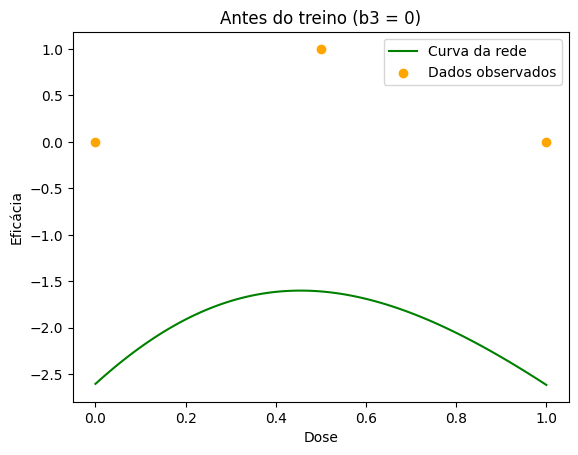

In [ ]:
def plot_curva(model, titulo):
    x_range = torch.linspace(0, 1, 100)
    with torch.no_grad():
        y_range = model(x_range)

    plt.plot(x_range, y_range, color='green', label='Curva da rede')
    plt.scatter(inputs, labels, color='orange', label='Dados observados', zorder=5)
    plt.xlabel('Dose')
    plt.ylabel('Eficácia')
    plt.title(titulo)
    plt.legend()
    plt.show()

plot_curva(model, "Antes do treino (b3 = 0)")

#### Melhoramento

In [ ]:
# SGD = Gradiente Descendente Estocástico
# b3 apenas ele será atualizado a cada passo.
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

num_epochs = 100
for epoch in range(num_epochs):
    # zera os gradientes acumulados
    optimizer.zero_grad()

    # forward pass
    predicoes = model(inputs)
    # SSR = soma dos quadrados dos resíduos
    loss = F.mse_loss(predicoes, labels, reduction='sum')

    # backpropagation: calcula d(loss)/d(b3)
    loss.backward()

    # atualiza b3 = b3 - lr * gradiente
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Época {epoch:3d} | b3 = {model.b3.item():.4f} | Loss (SSR) = {loss.item():.6f}")

print(f"\nValor final otimizado de b3: {model.b3.item():.4f}")

Época   0 | b3 = 1.5655 | Loss (SSR) = 20.423597
Época  10 | b3 = 2.6091 | Loss (SSR) = 0.000063
Época  20 | b3 = 2.6092 | Loss (SSR) = 0.000063
Época  30 | b3 = 2.6092 | Loss (SSR) = 0.000063
Época  40 | b3 = 2.6092 | Loss (SSR) = 0.000063
Época  50 | b3 = 2.6092 | Loss (SSR) = 0.000063
Época  60 | b3 = 2.6092 | Loss (SSR) = 0.000063
Época  70 | b3 = 2.6092 | Loss (SSR) = 0.000063
Época  80 | b3 = 2.6092 | Loss (SSR) = 0.000063
Época  90 | b3 = 2.6092 | Loss (SSR) = 0.000063

Valor final otimizado de b3: 2.6092


#### Gráfico

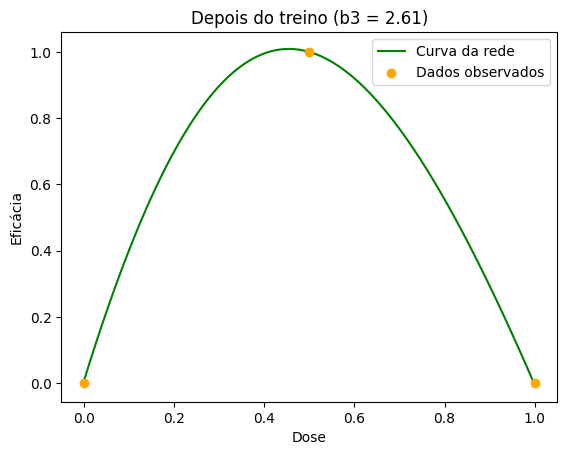

Previsões finais:  tensor([ 0.0055,  1.0002, -0.0057])
Valores reais:     tensor([0., 1., 0.])


In [ ]:
plot_curva(model, f"Depois do treino (b3 = {model.b3.item():.2f})")

with torch.no_grad():
    predicoes_finais = model(inputs)

print("Previsões finais: ", predicoes_finais)
print("Valores reais:    ", labels)

## G-1 ) Backpropagation

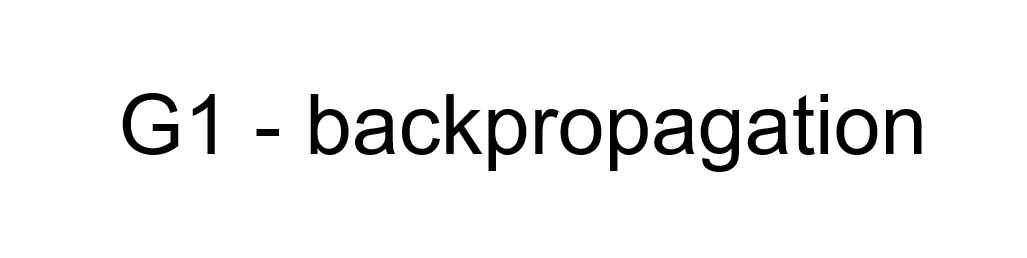

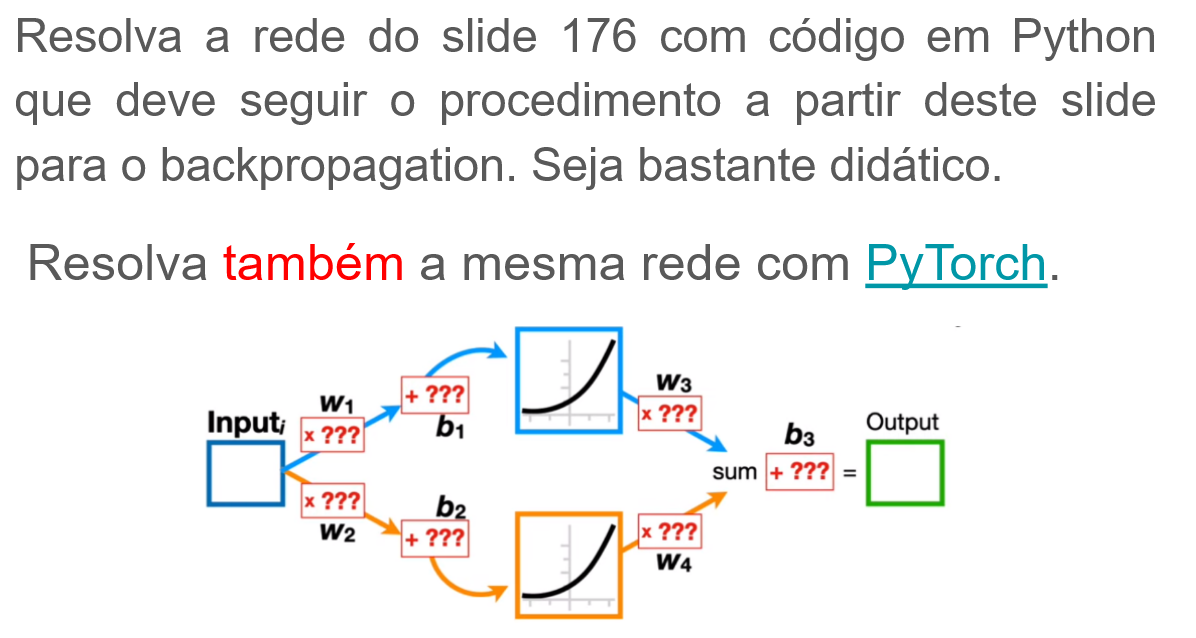

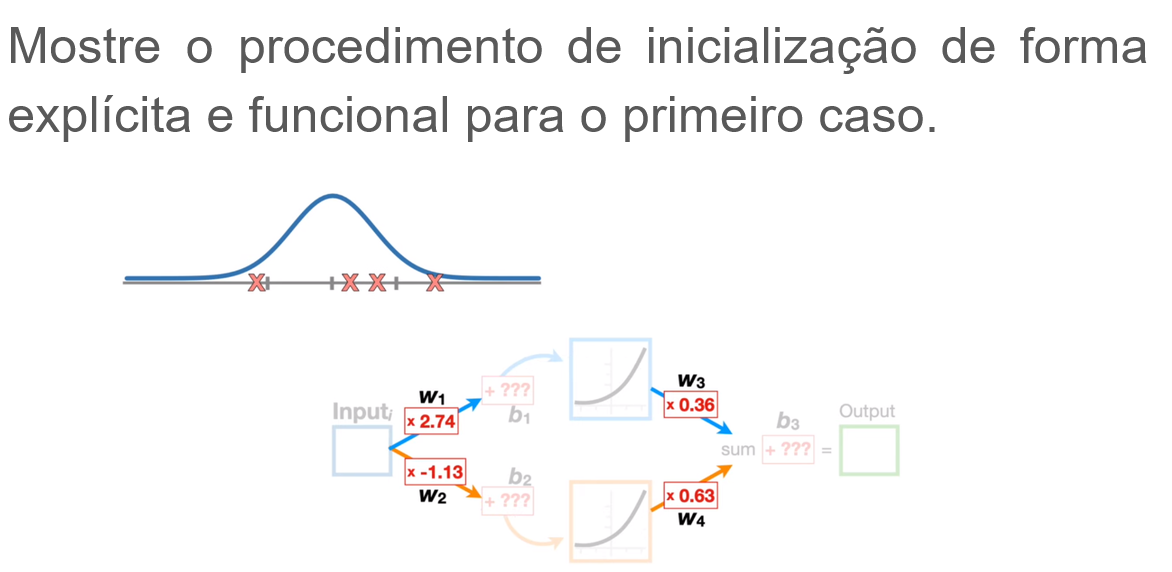

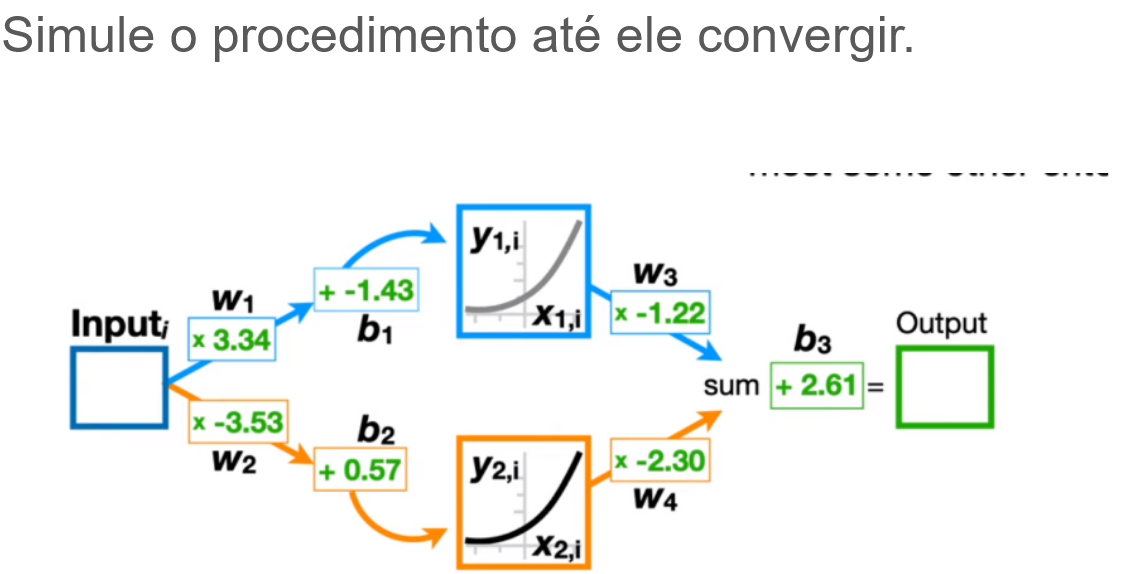

### Conceito

#### Rede Neural Artificial

Uma Rede Neural Artificial (RNA) é um modelo computacional inspirado no funcionamento dos neurônios do cérebro humano. Ela é formada por camadas de neurônios artificiais interligados por pesos e bias (vieses), que realizam operações matemáticas para transformar os dados de entrada em uma saída. Neste exercício, a rede possui uma camada de entrada, uma camada oculta composta por dois neurônios e uma camada de saída. Cada neurônio da camada oculta recebe a entrada, aplica uma transformação linear seguida da função de ativação SoftPlus e envia seu resultado para a camada de saída. O objetivo da rede é aprender os valores dos pesos e bias que melhor representem a relação entre a dosagem do remédio e sua eficácia.

#### SSR (Sum of Squared Residuals)

A Soma dos Quadrados dos Resíduos (SSR) é a função de custo utilizada para medir o erro da rede neural. Ela calcula a diferença entre os valores previstos pela rede e os valores reais do conjunto de treinamento, elevando essas diferenças ao quadrado e somando todos os resultados.

\[
SSR=\sum_{i=1}^{n}(y_i-\hat{y_i})^2
\]

Quanto menor for o valor da SSR, melhor será o ajuste da rede aos dados observados. Durante o treinamento, todo o processo de otimização busca minimizar essa função de custo, fazendo com que as previsões se aproximem cada vez mais dos valores esperados.

#### Backpropagation

O Backpropagation é o algoritmo responsável por calcular como cada peso e cada bias da rede influenciam o erro final. Após realizar o *forward pass* e calcular a SSR, o algoritmo percorre a rede no sentido inverso, da saída para a entrada, determinando o gradiente de cada parâmetro por meio da Regra da Cadeia do cálculo diferencial. Esses gradientes indicam a direção em que cada peso e bias deve ser ajustado para reduzir o erro da rede. Na implementação manual, todas essas derivadas são calculadas explicitamente. Já na implementação utilizando PyTorch, esse processo é realizado automaticamente pelo mecanismo **Autograd**, através da chamada `loss.backward()`.

#### Gradiente Descendente

O Gradiente Descendente é o algoritmo de otimização utilizado para atualizar os parâmetros da rede neural. Depois que o Backpropagation calcula os gradientes, cada peso e bias é atualizado na direção oposta ao gradiente, reduzindo gradualmente a função de custo. A atualização segue a equação:

\[
\theta = \theta - \alpha \frac{\partial SSR}{\partial \theta}
\]

onde \(\theta\) representa qualquer peso ou bias da rede e \(\alpha\) é a taxa de aprendizado (*learning rate*). Esse processo é repetido diversas vezes até que a SSR atinja um valor suficientemente pequeno, indicando que a rede encontrou um bom conjunto de parâmetros.

#### Épocas de Treinamento

Uma época corresponde a uma passagem completa de todo o conjunto de dados pelo processo de treinamento da rede neural. Em cada época, a rede realiza um *forward pass*, calcula a SSR, executa o Backpropagation para obter os gradientes e, por fim, atualiza todos os pesos e bias utilizando o Gradiente Descendente. Como uma única atualização geralmente não é suficiente para encontrar os melhores parâmetros, esse ciclo é repetido por diversas épocas. Neste exercício foram utilizadas **1500 épocas**, permitindo que a rede ajustasse progressivamente seus parâmetros e reduzisse o erro até obter previsões mais próximas dos valores observados.

### Código

#### Dados iniciais e Configurações

In [ ]:
# 1. Dados do problema (Dosagem do Remédio vs Eficácia)
# Entrada (X): Baixa (0.0), Média (0.5), Alta (1.0)
X = np.array([0.0, 0.5, 1.0])
# Saída Real (Y): Não funciona (0.0), Funciona (1.0), Não funciona (0.0)
Y = np.array([0.0, 1.0, 0.0])

# 2. Inicialização dos parâmetros exatamente como no slide 176
w1, b1 = 2.74, 0.0
w2, b2 = -1.13, 0.0
w3, w4, b3 = 0.36, 0.63, 0.0

# 3. Hiperparâmetros de treino
learning_rate = 0.1
epocas = 1500

# 4. Funções matemáticas auxiliares
def softplus(x):
    return np.log(1 + np.exp(x))

def d_softplus(x):
    # Derivada da softplus (função sigmoide)
    return 1 / (1 + np.exp(-x))

#### Backpropagation

In [ ]:
# Treinamento Manual
for epoca in range(epocas):
    # FORWARD PASS
    # Neurônio de cima (Node 1)
    x1 = X * w1 + b1
    y1 = softplus(x1)

    # Neurônio de baixo (Node 2)
    x2 = X * w2 + b2
    y2 = softplus(x2)

    # Camada de Saída (Output)
    previsao = y1 * w3 + y2 * w4 + b3

    # Cálculo do Erro (SSR)
    ssr = np.sum((Y - previsao) ** 2)

    # BACKPROPAGATION (Cálculo dos Gradientes de trás para frente)
    # Derivada do SSR em relação à previsão final
    d_previsao = -2 * (Y - previsao)

    # Gradientes da camada de saída
    d_w3 = np.sum(d_previsao * y1)
    d_w4 = np.sum(d_previsao * y2)
    d_b3 = np.sum(d_previsao * 1.0)

    # Gradientes da camada oculta (usando regra da cadeia com a derivada da softplus)
    d_x1 = d_previsao * w3 * d_softplus(x1)
    d_w1 = np.sum(d_x1 * X)
    d_b1 = np.sum(d_x1 * 1.0)

    d_x2 = d_previsao * w4 * d_softplus(x2)
    d_w2 = np.sum(d_x2 * X)
    d_b2 = np.sum(d_x2 * 1.0)

    # Mostrar os valores exatos do primeiro passo (slide 176) para validação
    if epoca == 0:
        print(f"\n[Gradientes Iniciais Calculados]:")
        print(f" d_w3: {d_w3:.2f}, d_w4: {d_w4:.2f}, d_b3: {d_b3:.2f}")
        print(f" d_w1: {d_w1:.2f}, d_b1: {d_b1:.2f}, d_w2: {d_w2:.2f}, d_b2: {d_b2:.2f}\n")

    # Atualiza os parâmetros (Gradiente Descendente)
    w1 -= learning_rate * d_w1
    b1 -= learning_rate * d_b1
    w2 -= learning_rate * d_w2
    b2 -= learning_rate * d_b2
    w3 -= learning_rate * d_w3
    w4 -= learning_rate * d_w4
    b3 -= learning_rate * d_b3

print(f"Treinamento finalizado! SSR final: {ssr:.6f}")
print(f"Previsões finais da rede: {previsao}")
print(f"Valores finais otimizados:")
print(f" w1 = {w1:.2f}, b1 = {b1:.2f}")
print(f" w2 = {w2:.2f}, b2 = {b2:.2f}")
print(f" w3 = {w3:.2f}, w4 = {w4:.2f}, b3 = {b3:.2f}")


[Gradientes Iniciais Calculados]:
 d_w3: 7.14, d_w4: 1.49, d_b3: 3.46
 d_w1: 0.76, d_b1: 0.97, d_w2: 0.33, d_b2: 0.73

Treinamento finalizado! SSR final: 0.000000
Previsões finais da rede: [6.92779167e-14 1.00000000e+00 6.88338275e-14]
Valores finais otimizados:
 w1 = 3.26, b1 = -1.93
 w2 = -3.35, b2 = 0.54
 w3 = -1.48, w4 = -2.25, b3 = 2.45


#### Backpropagation com Pytorch

In [ ]:
# Transformando dados em tensores do PyTorch
X_pt = torch.tensor([0.0, 0.5, 1.0], dtype=torch.float32)
Y_pt = torch.tensor([0.0, 1.0, 0.0], dtype=torch.float32)

# Definição da Arquitetura idêntica à do StatQuest
class RedeStatQuest(nn.Module):
    def __init__(self):
        super(RedeStatQuest, self).__init__()
        # Inicializando os parâmetros exatamente com as constantes dos slides
        self.w1 = nn.Parameter(torch.tensor(2.74))
        self.b1 = nn.Parameter(torch.tensor(0.0))
        self.w2 = nn.Parameter(torch.tensor(-1.13))
        self.b2 = nn.Parameter(torch.tensor(0.0))
        self.w3 = nn.Parameter(torch.tensor(0.36))
        self.w4 = nn.Parameter(torch.tensor(0.63))
        self.b3 = nn.Parameter(torch.tensor(0.0))

    def forward(self, x):
        # Passo para frente usando a ativação softplus nativa do PyTorch
        y1 = F.softplus(x * self.w1 + self.b1)
        y2 = F.softplus(x * self.w2 + self.b2)
        out = y1 * self.w3 + y2 * self.w4 + self.b3
        return out

# Instanciando o modelo
modelo = RedeStatQuest()

In [ ]:
# Definindo o otimizador SGD (Gradiente Descendente Estocástico)
otimizador = torch.optim.SGD(modelo.parameters(), lr=0.1)

print("Iniciando o treinamento com PyTorch...")

for epoca in range(1500):
    # Zera os gradientes acumulados da rodada anterior
    otimizador.zero_grad()

    # Forward Pass
    previsoes = modelo(X_pt)

    # Cálculo do Erro usando a métrica SSR (Soma dos Quadrados)
    loss = torch.sum((Y_pt - previsoes) ** 2)

    # Backpropagation Automático (O PyTorch descobre as derivadas sozinho aqui!)
    loss.backward()

    # Print para conferência dos primeiros gradientes gerados pelo PyTorch
    if epoca == 0:
        print(f"\n[Gradientes Iniciais do PyTorch]:")
        print(f" d_w3: {modelo.w3.grad.item():.2f}, d_w4: {modelo.w4.grad.item():.2f}, d_b3: {modelo.b3.grad.item():.2f}")
        print(f" d_w1: {modelo.w1.grad.item():.2f}, d_b1: {modelo.b1.grad.item():.2f}")

    # Atualização dos pesos
    otimizador.step()

print(f"\nTreinamento PyTorch finalizado! Perda (SSR) final: {loss.item():.6f}")
print(f"Previsões finais: {previsoes.detach().numpy()}")

Iniciando o treinamento com PyTorch...

[Gradientes Iniciais do PyTorch]:
 d_w3: 7.14, d_w4: 1.49, d_b3: 3.46
 d_w1: 0.76, d_b1: 0.97

Treinamento PyTorch finalizado! Perda (SSR) final: 0.000000
Previsões finais: [7.1525574e-07 9.9999809e-01 7.1525574e-07]


### Análise

#### Análise dos Resultados

Os gradientes calculados na primeira iteração representam a direção e a intensidade com que cada parâmetro da rede deveria ser ajustado para reduzir a função de custo (SSR). Observa-se que os maiores gradientes iniciais foram obtidos para os pesos da camada de saída (`w3 = 7.14` e `w4 = 1.49`) e para o bias da saída (`b3 = 3.46`), indicando que esses parâmetros eram os que mais contribuíam para o erro inicial da rede. Já os gradientes dos parâmetros da camada oculta (`w1`, `b1`, `w2` e `b2`) apresentaram valores menores, evidenciando que suas contribuições para a redução inicial do erro eram menos significativas.

Outro ponto importante é que os gradientes calculados manualmente coincidiram com os gradientes obtidos pelo PyTorch na primeira iteração. Esse resultado demonstra que a implementação manual do algoritmo de Backpropagation foi realizada corretamente, uma vez que o mecanismo de diferenciação automática (Autograd) do PyTorch produziu exatamente os mesmos valores para os parâmetros apresentados.

Ao término do treinamento manual, a função de custo (SSR) atingiu praticamente **zero**, indicando que a rede conseguiu aprender perfeitamente a relação entre as entradas e as saídas do conjunto de treinamento. As previsões finais foram aproximadamente:

- Entrada 0.0 → **6.93 × 10⁻¹⁴**
- Entrada 0.5 → **1.00**
- Entrada 1.0 → **6.88 × 10⁻¹⁴**

Esses valores são praticamente idênticos aos valores esperados **[0, 1, 0]**, mostrando que o modelo encontrou um conjunto de pesos capaz de reproduzir corretamente o comportamento desejado.

Na implementação utilizando PyTorch, a perda final também foi praticamente nula (**SSR = 0.000000**) e as previsões obtidas foram:

- Entrada 0.0 → **7.15 × 10⁻⁷**
- Entrada 0.5 → **0.999998**
- Entrada 1.0 → **7.15 × 10⁻⁷**

Embora essas previsões não sejam exatamente iguais às da implementação manual, as diferenças são extremamente pequenas (da ordem de 10⁻⁷), sendo decorrentes da precisão numérica utilizada pelo PyTorch (`float32`) e da forma como as operações são realizadas internamente. Na prática, ambos os modelos produziram resultados equivalentes.

De maneira geral, os resultados mostram que tanto a implementação manual quanto a implementação utilizando PyTorch foram capazes de treinar corretamente a rede neural. Além disso, a coincidência dos gradientes iniciais e a obtenção de uma função de custo praticamente nula validam tanto a implementação do algoritmo de Backpropagation quanto o processo de otimização realizado pelo Gradiente Descendente.